# Congestion Revenue Allocation on the WSCC 9-Bus Network

> **Work in progress** — an illustrative teaching notebook under active development, not an authoritative reference.

This notebook is about how two **balancing authorities (BAs)** co-optimizing one nodal dispatch on the shared
9-bus network generate and allocate
**congestion rent** (and, in the last section, the **transfer rent** of an
optimised interchange). Example methods are considered: 

Method 1 - each BA keeps the rent on the lines it manages vs 

Method 2 - each BA keeps the congestion revenue its own gen-to-load use creates ($N^c_a$).

It assumes the fundamentals notebook (nodal LMPs, the congestion-rent identity,
transport constraints, self-schedules) and goes straight to the allocation issue.
Everything runs on the shared libraries — `wscc9_model`, `footprints`,
`revenue_allocation`, `wscc9_figures`.

## 0. Setup

In [1]:
#@title ▶ Run me first — Colab setup (installs packages, fetches the helper modules)
# On Google Colab this installs the few non-default packages and downloads the
# three helper modules next to the notebook. Running locally it does nothing
# (the modules are already on disk), so the same notebook works in both places.
import sys, subprocess

def _sh(cmd):
    print("$", cmd)
    subprocess.run(cmd, shell=True, check=True)

if "google.colab" in sys.modules:
    _sh("pip install -q pypsa pandapower pycirclize")
    _base = "https://raw.githubusercontent.com/pdockery/wscc9-illustrative-model/main"
    for _f in ("ieee9_network.py", "seams_engine.py", "nodal_plot.py",
              "wscc9_model.py", "footprints.py", "revenue_allocation.py", "wscc9_figures.py"):
        _sh(f"wget -q {_base}/{_f} -O {_f}")
    print("Colab setup complete.")
else:
    print("Local run: using the modules already in this folder.")


Local run: using the modules already in this folder.


In [2]:
import sys, os, importlib
import warnings; warnings.filterwarnings('ignore')
import logging; logging.getLogger('pypsa').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('.'))

# Teaching libraries for the WSCC 9-bus illustrative repository.
import seams_engine, nodal_plot, wscc9_model, footprints, revenue_allocation, wscc9_figures
for _m in (seams_engine, nodal_plot, wscc9_model, footprints, revenue_allocation, wscc9_figures):
    importlib.reload(_m)
import wscc9_model as wm, footprints as fpmod, revenue_allocation as ra, wscc9_figures as figs
from wscc9_model import (
    build_network, make_engine, shift_factors, sf_table,
    BUS_COLORS, COORDS, RING_ORDER, ROTATION_DEG, CENTER_BUS,
)
from seams_engine import (
    compute_ptdf, MarketEngine, solve_engine_dispatch, solve_engine_qp,
    physical_flows, seam_dual_gap, to_supply_demand, susceptance_widths,
    shed_segments, served_by_bus, served_demand,
)
from nodal_plot import (
    plot_network_topology, plot_nodal_circlize, plot_combined_letter,
    assign_bus_colors, BUS_PALETTE, TRANSIT_COLOR,
)
pd.set_option('display.width', 160)

def _df_to_latex(_df):
    if isinstance(_df, pd.Series):
        _df = _df.to_frame()
    _body = _df.to_latex(escape=True, na_rep='', float_format=lambda v: f'{(0.0 if v==0 else v):,.6g}')
    _ncol = _df.shape[1] + _df.index.nlevels
    if _ncol > 6:
        return '\\begin{center}\\resizebox{\\linewidth}{!}{%\n' + _body + '}\\end{center}'
    return '\\begin{center}{\\small\n' + _body + '}\\end{center}'

try:
    _ltx = get_ipython().display_formatter.formatters['text/latex']
    _ltx.for_type(pd.DataFrame, _df_to_latex)
    _ltx.for_type(pd.Series, _df_to_latex)
except Exception:
    pass

# Combined-figure sizing for 8.5-inch-wide print: a taller, balanced side-by-side (network and
# dispatch ring at roughly equal visual weight) with every label floored to >= 10pt at 8.5 in
# wide. The taller/ring-shifted layout and panel-title placement live in plot_combined_letter's
# compact mode (triggered by the sub-10-inch width). Call size_for_print(fig) after building one.
import matplotlib.text as _mtext
CB_SIZE, CB_RATIOS = (8.5, 5.9), (1.08, 0.92)
def size_for_print(fig, min_pt=10.0, print_w=8.5):
    floor = min_pt * fig.get_size_inches()[0] / print_w
    for t in fig.findobj(_mtext.Text):
        if t.get_text().strip() and t.get_fontsize() < floor:
            t.set_fontsize(floor)
    return fig

print('ready')

ready

In [3]:
# The teaching fleet and loads live in wscc9_model (edit there, or override the
# dicts here). Bus 3 is the cheapest unit ($20), bus 1 the most expensive ($50).
GEN_FLEET = dict(wm.DEFAULT_GEN_FLEET)   # {gen: {bus, cost $/MWh, p_nom MW}}
LOADS     = dict(wm.DEFAULT_LOADS)       # {bus: MW}
print('loads (MW):', LOADS)
pd.DataFrame(GEN_FLEET).T[['bus', 'cost', 'p_nom']]

loads (MW):

{'5': 90.0, '7': 100.0, '9': 125.0}

,bus,cost,p_nom
gen_slack_0,1,50.0,250.0
gen_0,2,35.0,300.0
gen_1,3,20.0,170.0


## 1. Accounting for transmission constraints

Nodal markets find the least-cost dispatch that serves demand with offered generation while respecting the network's constraints. A market clears over a **subset** of the power system:

$$\mathcal R^{\mathcal A}\subseteq\mathcal R\ \ \text{(the resources it dispatches)},\qquad
  \mathcal N^{\mathcal A}\subseteq\mathcal N\ \ \text{(the load it serves)},\qquad
  \mathcal M^{\mathcal A}_{\mathrm{act}}\subseteq\mathcal M\ \ \text{(the lines it monitors)}.$$

A bus inside the market area is **optimised**; a bus outside it enters as a fixed schedule $\mathrm{exo}_n$:

$$p_n=\begin{cases}\ \displaystyle\sum_{i\in\mathcal R^{\mathcal A}:\,\mathrm{bus}(i)=n} g_i\ -\ d_n, & n\in\mathcal N^{\mathcal A},\\[2mm]\ \mathrm{exo}_n, & n\notin\mathcal N^{\mathcal A}.\end{cases}\qquad(1)$$

Flows follow the injections linearly: a net injection of $p$ MW at bus $n$ loads line $m$ by $SF_{n,m}\,p$, so $F_m=\sum_n SF_{n,m}\,p_n$, where the shift factor $SF_{n,m}$ is bus $n$'s leverage on line $m$.

### The clearing problem and its prices

Minimise production cost subject to (i) the power-balance constraint, (ii) flow limits on the monitored lines, and (iii) net-interchange (transfer) limits between balancing authorities:

$$\min_{0\le g_i\le\bar g_i}\ \sum_{i\in\mathcal R^{\mathcal A}} C_i(g_i)\quad\text{s.t.}\quad
\begin{cases}
\ \displaystyle\sum_{i\in\mathcal R^{\mathcal A}} g_i=\sum_{n\in\mathcal N^{\mathcal A}} d_n & [\lambda]\quad\text{power balance}\\[1mm]
\ -\bar F_m\le F_m\le\bar F_m & [\mu_m],\ m\in\mathcal M^{\mathcal A}_{\mathrm{act}}\quad\text{line limits}\\[1mm]
\ -\bar E\le E\le\bar E & [\mu_T]\quad\text{transfer limit}
\end{cases}\qquad(2)$$

Enforcing constraints comes at a price: each shadow price is what it would be worth to relax that constraint. $\lambda$ is the cost of serving one more MW on the system, $\mu_m$ the value of one more MW of limit on line $m$, and $\mu_T$ the value of one more MW of transfer. The Lagrangian collects them:

$$\mathcal L(g,\lambda,\mu_m,\mu_T)=\sum_{i\in\mathcal R^{\mathcal A}} C_i(g_i)-\lambda\Big(\sum_{i\in\mathcal R^{\mathcal A}} g_i-\sum_{n\in\mathcal N^{\mathcal A}} d_n\Big)-\!\!\sum_{m\in\mathcal M^{\mathcal A}_{\mathrm{act}}}\!\!\mu_m\,F_m-\mu_T\,E.\qquad(3)$$

A locational marginal price at every bus drops out of stationarity — the system price plus each binding shadow price, weighted by how much an injection at $n$ moves the constraint it prices (the shift factor $SF_{n,m}$ for a line; the indicator $\mathbb 1\{n\in\mathcal N_1\}$ for the transfer, equal to $1$ when bus $n$ lies inside the footprint $\mathcal N_1$ whose net export the transfer caps):

$$\lambda_n=\lambda+\sum_{m\in\mathcal M^{\mathcal A}_{\mathrm{act}}} SF_{n,m}\,\mu_m+\mathbb 1\{n\in\mathcal N_1\}\,\mu_T.\qquad(4)$$

### Congestion and transfer rent

The LMP collects enough revenue to pay generation plus the cost of respecting the line and transfer constraints. Net the bus-level payments — the energy components cancel because total generation equals total load:

$$\underbrace{\sum_{n\in\mathcal N^{\mathcal A}}\lambda_n d_n}_{\text{revenue from load}}\ -\ \underbrace{\sum_{i\in\mathcal R^{\mathcal A}}\lambda_{\mathrm{bus}(i)} g_i}_{\text{payments to generation}}\ =\ \underbrace{-\!\!\sum_{m\in\mathcal M^{\mathcal A}_{\mathrm{act}}}\!\!\mu_m F_m}_{\text{congestion rent}}\ \underbrace{-\ \mu_T E}_{\text{transfer rent}}.\qquad(5)$$

The cost of respecting the line and transfer constraints is two rents — the congestion rent on the lines this market monitors, and the transfer rent on its scheduled interchange:

$$R=\!\!\sum_{m\in\mathcal M^{\mathcal A}_{\mathrm{act}}}\!\!\big|\,\mu_m F_m\,\big|,\qquad\qquad R_T=\big|\,\mu_T E\,\big|.\qquad(6)$$

Both rents are **limited to within the market area**: $R$ sums only over $\mathcal M^{\mathcal A}_{\mathrm{act}}$, the monitored elements. The congestion rent a market collects is the scarcity priced on **its own portion of the network** — the quantity the rest of this notebook allocates between two balancing authorities. **No binding constraint $\Rightarrow$ no price separation $\Rightarrow R=0$.**

*In the examples that follow through Section 4 only line limits bind, so $\mu_T=0$ and $R_T=0$; the transfer limit is put to work in Section 5.*

**Edit below:** generator costs, load levels, and line ratings. Limiting a line rating may
create congestion and price separation on the constrained
path.

In [4]:
# -- EDIT -- unified-clearing inputs --------------------------------------
COST_OVERRIDE   = {}                      # e.g. {'gen_0': 45.0} to re-bid the $35 unit
LOAD_OVERRIDE   = {}                      # e.g. {'7': 130.0}
LINE_RATINGS    = {'line_4': 40.0}   # adjust line_4 (6-7, internal to BA-1) below its ~63 MW natural flow
SHED_PRICE      = 150.0   # $/MWh -- load-shed (power-balance relaxation) penalty; None disables
# -------------------------------------------------------------------------

net = build_network(LINE_RATINGS)
pt  = compute_ptdf(net, slack_bus='1')

unified = make_engine('UNIFIED', buses=pt.buses)
for g, c in COST_OVERRIDE.items(): unified.gens[g]['cost'] = c
for b, v in LOAD_OVERRIDE.items(): unified.loads[b] = v

res = solve_engine_dispatch(pt, unified, shed_price=SHED_PRICE)
print('dispatch (MW):', {k: round(v, 1) for k, v in res.dispatch.items()})
print('energy price :', round(res.energy_price, 2), '$/MWh')
binding = {k: round(v, 1) for k, v in res.line_dual.items() if abs(v) > 1e-3}
print('binding lines:', binding or 'none')
print('load shed    :', {b: round(v, 1) for b, v in res.shed_by_bus.items()} or 'none')
print()
print('LMP by bus ($/MWh):')
pd.Series({b: round(res.lmp[b], 2) for b in pt.buses}).to_frame('LMP').T

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


dispatch (MW):

{'gen_slack_0': 0.0, 'gen_0': 176.1, 'gen_1': 138.9}

energy price :

27.74

...

{'line_4': -20.1}

load shed    :

none

LMP by bus ($/MWh):

,1,2,3,4,5,6,7,8,9
LMP,27.74,35.0,20.0,27.74,25.02,20.0,37.13,35.0,30.25


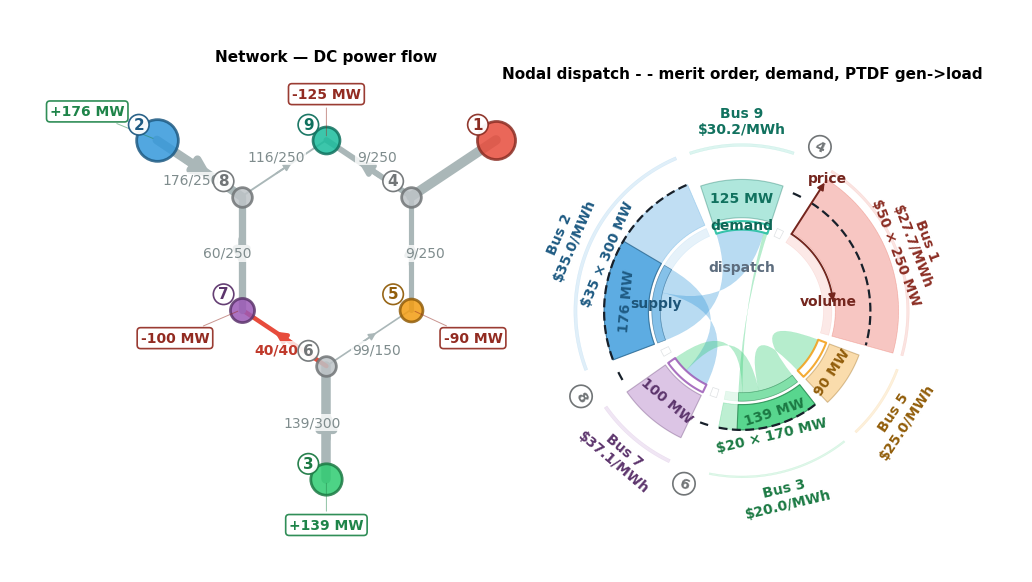

In [5]:
# The two-panel composite of the unified clearing: the network (left) now labelled
# with each bus's net injection (+) / withdrawal (-) -- the same technique as the
# three-dispatch views in Section 3 -- and the nodal dispatch ring (right), where the
# LMPs are read. This is the set-up view; the BA split and allocation come next.
sup, dem = to_supply_demand(unified, res)
colors = dict(BUS_COLORS)
binding_lines = {l for l, mu in res.line_dual.items() if abs(mu) > 1e-3}
bus_net = {b: float(res.injection[pt.bus_idx[b]]) for b in pt.buses}   # net gen - load per bus
fig, (ax_net, ax_circ) = plot_combined_letter(
    net, sup, dem,
    bus_colors=colors, bus_lmps=res.lmp, bus_net_mw=bus_net, network_show_lmp=False,
    line_flows={l: res.flow_own[l] for l in pt.lines},
    line_widths=susceptance_widths(pt), constrained_lines=binding_lines,
    flows=nodal_plot.compute_ptdf_flows(net, sup, served_demand(res, dem)),
    clearing_price=res.energy_price,
    demand_segments=shed_segments(res, dem),
    lmp_line=True, annotate_roles=True, axis_key=True,
    all_buses=pt.buses, sector_order=RING_ORDER,
    bus_coords=COORDS, center_bus=CENTER_BUS,
    title_right='Nodal dispatch - - merit order, demand, PTDF gen->load',
    figsize=CB_SIZE, panel_ratios=CB_RATIOS,
)
size_for_print(fig)
plt.show()

In [6]:
# === Congestion-rent ledger: how the merchandising surplus arises (eqs. 5-6) ===
# The bus-level and constraint-level accounting -- the same two tables shown later per BA --
# here for the unified clearing. Congestion rent R appears two ways (eqs. 5-6):
#   (1) settlement by node: paid by load and paid to gen at every bus; the
#       'Total - congestion rent' row is load payments minus generation payments;
#   (2) marginal value of line capacity: each line's |shadow price| x flow, the 'TOTAL'
#       row summing to the same R (the 'binding' column flags every line that constrains).
from revenue_allocation import settlement_by_bus, capacity_value_by_line

node_ledger = settlement_by_bus(res, pt.buses, unified.loads)
_lp = node_ledger.loc['SUBTOTAL', 'paid by load ($/h)']
_gp = node_ledger.loc['SUBTOTAL', 'paid to gen ($/h)']
node_ledger.loc['Total - congestion rent'] = ['', '', '', '', round(_lp - _gp, 1)]

print('Settlement by node (unified clearing):')
display(node_ledger)
print('Marginal value of line capacity -- shadow price x flow (TOTAL = congestion rent):')
display(capacity_value_by_line(res, pt, pt.lines))

Settlement by node (unified clearing):

,LMP ($/MWh),gen (MW),paid to gen ($/h),load (MW),paid by load ($/h)
bus,,,,,
1,27.74,0.0,0.0,0.0,0.0
2,35.0,176.1,6162.4,0.0,0.0
3,20.0,138.9,2778.6,0.0,0.0
4,27.74,0.0,0.0,0.0,0.0
5,25.02,0.0,0.0,90.0,2251.8
6,20.0,0.0,0.0,0.0,0.0
7,37.13,0.0,0.0,100.0,3712.6
8,35.0,0.0,0.0,0.0,0.0
9,30.25,0.0,0.0,125.0,3780.8


Marginal value of line capacity -- shadow price x flow (TOTAL = congestion rent):

,from,to,flow (MW),rating (MW),binding,|mu| ($/MWh = value of +1 MW),rent |mu| x flow ($/h)
line,,,,,,,
line_0,1,4,-0.0,250.0,False,0.0,0.0
line_1,4,5,-8.9,250.0,False,0.0,0.0
line_2,5,6,-98.9,150.0,False,0.0,0.0
line_3,3,6,138.9,300.0,False,0.0,0.0
line_4,6,7,40.0,40.0,True,20.1,804.1
line_5,7,8,-60.0,250.0,False,0.0,0.0
line_6,8,2,-176.1,250.0,False,0.0,0.0
line_7,8,9,116.1,250.0,False,0.0,0.0
line_8,9,4,-8.9,250.0,False,0.0,0.0


## 2. Two balancing authorities on the shared network

In [7]:
## -- EDIT -- the two balancing authorities, and the lines each manages.
BA_DEFS = {
    'BA-1': ['2', '8', '7', '6', '3'],   # cheap fleet (bus 3 $20, bus 2 $35); load at 7 -> exporter
    'BA-2': ['1', '9', '4', '5'],         # only the bus-1 unit ($50); loads at 5 and 9 -> importer
}
BA_LINES = {  # any line may be listed under either BA; a line under neither is unassigned (grey, rent split 50/50)
    'BA-1': ['line_2', 'line_3', 'line_4', 'line_5', 'line_6'],   # line_2 = tie 5-6
    'BA-2': ['line_0', 'line_1', 'line_7', 'line_8'],             # line_7 = tie 8-9
}
BA_COLORS = {'BA-1': '#993AFF', 'BA-2': '#2471A3'}
# ---------------------------------------------------------------------------
pt = shift_factors()
fp = fpmod.make(pt, BA_DEFS, BA_COLORS, manage=BA_LINES, tie_label='tie')

# Notebook aliases so the methodology/figure cells below read naturally.
ba_of = fp.fp_of
LINE_BA = fp.line_assign
AREAS = fp.areas
ties = fp.ties
LOADS_ALL = dict(LOADS)
line_kind = lambda _pt, l: fp.line_kind(_pt, l)
ba_line_colors = lambda _pt: fp.line_colors(_pt)
BA_GROUPS = fp.groups(pt)

print('BA-1 buses:', BA_DEFS['BA-1'], '| manages:', [l for l in pt.lines if LINE_BA[l] == 'BA-1'])
print('BA-2 buses:', BA_DEFS['BA-2'], '| manages:', [l for l in pt.lines if LINE_BA[l] == 'BA-2'])
print('tie lines:', ties, '| unassigned:', [l for l in pt.lines if LINE_BA[l] is None] or 'none')

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


BA-1 buses:

['2', '8', '7', '6', '3']

| manages:

['line_2', 'line_3', 'line_4', 'line_5', 'line_6']

...

['line_0', 'line_1', 'line_7', 'line_8']

tie lines:

['line_2', 'line_7']

| unassigned:

none

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


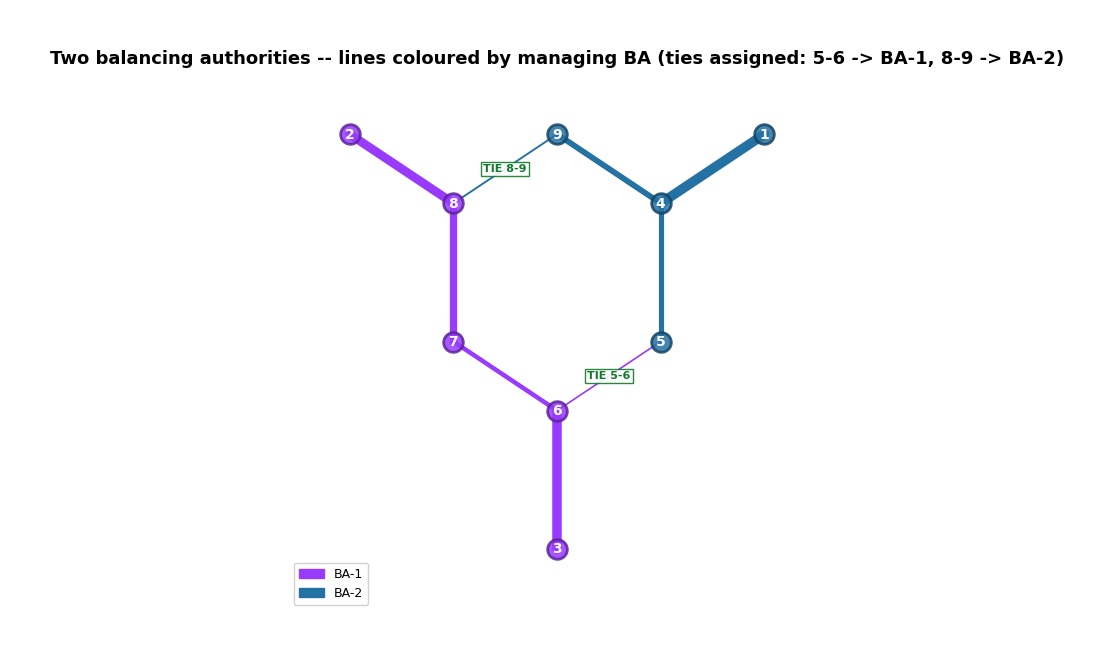

In [8]:
# Map of the two BAs and the interconnectors (buses coloured by BA).
ba_bus_colors = {b: BA_COLORS[ba_of(b)] for b in pt.buses}
fig, ax = plot_network_topology(
    build_network(), supply_by_bus={}, demand_by_bus={},
    bus_colors=ba_bus_colors, bus_coords=COORDS,
    line_flows={l: 0.0 for l in pt.lines}, line_widths=susceptance_widths(pt),
    line_colors=ba_line_colors(pt),   # lines coloured by the BA that manages them (LINE_BA); unassigned grey
    title='Two balancing authorities -- lines coloured by managing BA (ties assigned: 5-6 -> BA-1, 8-9 -> BA-2)',
)
for l in ties:
    i = pt.line_idx[l]; b0, b1 = pt.line_buses[i]
    x0, y0 = COORDS[b0]; x1, y1 = COORDS[b1]
    ax.text((x0+x1)/2, (y0+y1)/2, f'TIE {b0}-{b1}', fontsize=8, fontweight='bold',
            color='#117A2B', ha='center', va='center',
            bbox=dict(fc='white', ec='#117A2B', alpha=0.9, pad=1.5), zorder=7)
import matplotlib.patches as mpatches
ax.legend(handles=[mpatches.Patch(color=BA_COLORS[ba], label=ba) for ba in BA_DEFS],
          loc='lower left', fontsize=9, framealpha=0.9)
plt.show()

## 3. One constraint, three dispatches

An illustrative model moves the accounting of Section 1 from formulas to pictures. On the WSCC 9-bus case -- 3 loads, 3 generators, 9 lines, split into the two balancing authorities of Section 2 -- hold one binding internal corridor (`line_4`, the 6--7 line inside BA-1) at 40 MW and watch price and dispatch as BA-1 brings progressively more of the shared grid into view. The neighbour is (1) **ignored**, (2) **accommodated**, or (3) **optimised**.

Each view is one combined picture: the network DC flow on the left (each bus annotated with its **net injection** $+$ / **withdrawal** $-$; read price off the dispatch ring on the right) and a **Transfers** inset for the net interchange $E$ between the two areas.

1. **Dispatch 1 -- ignoring the neighbour.** BA-1 serves only its own bus-7 load on its own lines; the rest of the grid carries no injection. Its corridor already binds. Not a base case, but a clean starting point -- what BA-1's production cost would be if no one else used the transmission system.
2. **Dispatch 2 -- accommodating the neighbour.** BA-2's autarky pattern (its dear bus-1 unit serving its own load at buses 5 and 9) is placed on the grid as fixed injections BA-1 does not optimise. That pattern puts **loop flow** on the already-full `line_4`, so BA-1 redispatches -- a cost it bears silently for a flow no settlement prices.
3. **Dispatch 3 -- optimising with the neighbour.** Both areas co-optimised. The same physics that cost BA-1 an unpriced redispatch is now a priced, collectable congestion rent $R$, separated across the seam into BA-2.

The tables then read the sequence as money: production cost by region (the silent redispatch, then the gains from unified dispatch), and the congestion rent the unified market collects, by area.

In [9]:
# === The three dispatches behind the congestion rent ===
# One binding internal corridor (line_4 = 40 MW) read three ways. The interchange E is shown in
# each figure's Transfers inset but never binds (Ebar = combined tie rating).
from seams_engine import solve_engine_dispatch

D_RAT  = {'line_4': 40.0}                                  # the binding internal corridor
netD = build_network(D_RAT); ptD = compute_ptdf(netD, slack_bus='1')
D_EBAR = float(sum(ptD.s_nom[ptD.line_idx[l]] for l in ties))   # interchange shown, not binding
COST = {g: s['cost'] for g, s in wm.DEFAULT_GEN_FLEET.items()}
GBUS = {g: s['bus']  for g, s in wm.DEFAULT_GEN_FLEET.items()}
def _pcost(res, ba=None):
    return sum(res.dispatch.get(g, 0.0) * COST[g] for g in COST
               if ba is None or GBUS[g] in BA_DEFS[ba])

# BA-2's autarky pattern -- the dear bus-1 unit serving its own 5/9 load -- as fixed injections.
BA2_EXO  = {'1': sum(LOADS_ALL[b] for b in BA_DEFS['BA-2'] if b in LOADS_ALL),  # bus-1 covers BA-2 load
            '5': -LOADS_ALL['5'], '9': -LOADS_ALL['9']}
BA2_FUEL = BA2_EXO['1'] * COST['gen_slack_0']              # that energy from the $50 bus-1 unit

ix = (BA_DEFS['BA-1'], D_EBAR)
eng1 = make_engine('BA-1', buses=BA_DEFS['BA-1'])
res1 = solve_engine_dispatch(ptD, eng1, interchange=ix, shed_price=SHED_PRICE)
eng2 = make_engine('BA-1', buses=BA_DEFS['BA-1'])
res2 = solve_engine_dispatch(ptD, eng2, exo=BA2_EXO, interchange=ix, shed_price=SHED_PRICE)
eng3 = make_engine('UNIFIED', buses=ptD.buses)
res3 = solve_engine_dispatch(ptD, eng3, interchange=ix, shed_price=SHED_PRICE)
R3   = sum(abs(res3.line_dual[l]) * abs(res3.flow_own[l]) for l in ptD.lines)   # unified congestion rent (~$804/h)

# Production cost by region (BA-2's entry is its autarky production cost; it is idle in the islanded view).
pcost_tbl = pd.DataFrame(
    {'BA-1 prod cost': [_pcost(res1, 'BA-1'), _pcost(res2, 'BA-1'), _pcost(res3, 'BA-1')],
     'BA-2 prod cost': [0.0,                  BA2_FUEL,             _pcost(res3, 'BA-2')]},
    index=['1. BA-1 islanded', '2. neighbour fixed', '3. unified'])
pcost_tbl['system prod cost'] = pcost_tbl.sum(axis=1)
print('Production cost by region ($/h):')
display(pcost_tbl.round(0))
redisp = pcost_tbl.loc['2. neighbour fixed', 'BA-1 prod cost'] - pcost_tbl.loc['1. BA-1 islanded', 'BA-1 prod cost']
gains  = pcost_tbl.loc['2. neighbour fixed', 'system prod cost'] - pcost_tbl.loc['3. unified', 'system prod cost']
print(f"  D1 -> D2: BA-1's silent redispatch for the neighbour's loop flow = ${redisp:,.0f}/h")
print(f"  D2 -> D3: gains from unified dispatch (both serve all 315 MW) = ${gains:,.0f}/h")

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


Production cost by region ($/h):

,BA-1 prod cost,BA-2 prod cost,system prod cost
1. BA-1 islanded,2909.0,0.0,2909.0
2. neighbour fixed,2978.0,10750.0,13728.0
3. unified,8941.0,0.0,8941.0


  D1 -> D2: BA-1's silent redispatch for the neighbour's loop flow = $69/h

  D2 -> D3: gains from unified dispatch (both serve all 315 MW) = $4,787/h

### The same three dispatches, with rising supply curves

Flat offer prices give a unit the *same* marginal cost whether it runs at 35 MW or 65 MW, so a flow-driven redispatch moves quantities without moving any price. This section gives each unit a **linear, upward-sloping** marginal cost $MC_g(g)=a_g+b_g\,g$ instead (a continuous QP via `solve_engine_qp`).

In [10]:
# === Rising linear MC curves on the same three dispatches (continuous QP) ===
# Reuses the scaffolding from the flat section above: netD, ptD, fp, D_EBAR, BA2_EXO,
# ix, SHED_PRICE, LOADS_ALL, and the flat results res1/res2/res3 (used as q* anchors
# and to fix each clearing's binding-line set).
CURVE_SPAN = 5.0    # -- EDIT -- $/MWh the marginal cost sits BELOW the flat offer at zero output;
                    #            it rises back to the flat offer c0 at the unified dispatch q*. 0 = flat.

QSTAR = dict(res3.dispatch)                                    # unified dispatch = the anchor
C0    = {g: s['cost'] for g, s in wm.DEFAULT_GEN_FLEET.items()}
def _curve(g):
    qx = QSTAR.get(g, 0.0)
    if qx < 1.0:                                               # idle under unification (bus 1)
        return (C0[g] - CURVE_SPAN, 0.04)                      #   keep it dear: 45 -> 55, never cheap
    return (C0[g] - CURVE_SPAN, CURVE_SPAN / qx)               # MC(0)=c0-SPAN, MC(q*)=c0 (gentle)
CURVES = {g: _curve(g) for g in wm.DEFAULT_GEN_FLEET}          # one curve per unit, used everywhere

curve_tbl = pd.DataFrame(
    {'bus':   [wm.DEFAULT_GEN_FLEET[g]['bus'] for g in CURVES],
     'a ($/MWh)': [round(a, 2) for a, _ in CURVES.values()],
     'b ($/MWh/MW)': [round(b, 4) for _, b in CURVES.values()],
     'MC(0)':  [round(a, 1) for a, _ in CURVES.values()],
     'MC(q*)': [round(a + b * QSTAR.get(g, 0.0), 1) for g, (a, b) in CURVES.items()],
     'flat c0': [C0[g] for g in CURVES]},
    index=list(CURVES))
print('Linear marginal-cost curves  MC_g(g) = a + b*g   (anchored MC(q*) = flat c0):')
display(curve_tbl)

def _qp(name, buses, flat_res, **kw):
    bind = [l for l, v in flat_res.line_dual.items() if abs(v) > 1e-3]   # active set from flat solve
    return solve_engine_qp(ptD, make_engine(name, buses=buses), curves=CURVES,
                           interchange=ix, shed_price=SHED_PRICE, binding_lines=bind, **kw)
res1q = _qp('BA-1', BA_DEFS['BA-1'], res1)
res2q = _qp('BA-1', BA_DEFS['BA-1'], res2, exo=BA2_EXO)
res3q = _qp('UNIFIED', ptD.buses, res3)

# production cost = area under MC = a*g + 0.5*b*g^2
def _pcq(res, ba=None):
    return sum(CURVES[g][0] * res.dispatch.get(g, 0.0) + 0.5 * CURVES[g][1] * res.dispatch.get(g, 0.0) ** 2
               for g in CURVES if (ba is None or GBUS[g] in BA_DEFS[ba]) and g in res.dispatch)

idx = ['1. islanded', '2. neighbour', '3. unified']
cmp_tbl = pd.DataFrame(
    {'LMP@7 flat':   [res1.lmp['7'],  res2.lmp['7'],  res3.lmp['7']],
     'LMP@7 rising': [res1q.lmp['7'], res2q.lmp['7'], res3q.lmp['7']],
     'BA-1 prod cost (rising)': [_pcq(res1q, 'BA-1'), _pcq(res2q, 'BA-1'), _pcq(res3q, 'BA-1')]},
    index=idx)
print('\nFlat offers price all three the same; rising curves separate them:')
display(cmp_tbl.round(2))
print(f"  islanded->neighbour: the loop flow now reprices bus 7 by "
      f"${res2q.lmp['7'] - res1q.lmp['7']:+.2f}/MWh (flat: $0.00) ...")
print(f"  ... and the unified clearing is unchanged: LMP@7 = ${res3q.lmp['7']:.4f} "
      f"(flat ${res3.lmp['7']:.4f}), E = {res3q.interchange_mw:.0f} MW -- the Section-4 ledger holds.")

Linear marginal-cost curves  MC_g(g) = a + b*g   (anchored MC(q*) = flat c0):

,bus,a ($/MWh),b ($/MWh/MW),MC(0),MC(q*),flat c0
gen_slack_0,1,45.0,0.0400,45.0,45.0,50.0
gen_0,2,30.0,0.0284,30.0,35.0,35.0
gen_1,3,15.0,0.0360,15.0,20.0,20.0



Flat offers price all three the same; rising curves separate them:

,LMP@7 flat,LMP@7 rising,BA-1 prod cost (rising)
1. islanded,37.13,33.89,2488.57
2. neighbour,37.13,34.06,2559.89
3. unified,37.13,37.13,8153.53


  islanded->neighbour: the loop flow now reprices bus 7 by $+0.17/MWh (flat: $0.00) ...

  ... and the unified clearing is unchanged: LMP@7 = $37.1260 (flat $37.1260), E = 215 MW -- the Section-4 ledger holds.

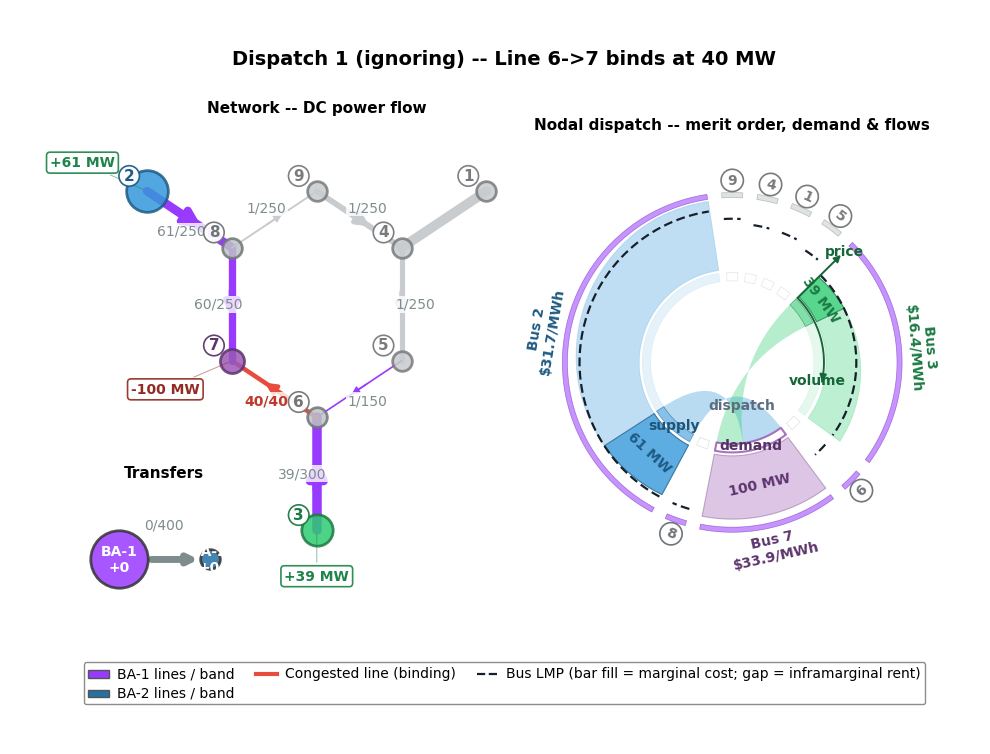

Dispatch 1 (ignoring) -- settlement by node:

,LMP ($/MWh),gen (MW),paid to gen ($/h),load (MW),paid by load ($/h)
bus,,,,,
2,31.72,60.6,1921.2,0.0,0.0
8,31.72,0.0,0.0,0.0,0.0
7,33.89,0.0,0.0,100.0,3388.9
6,16.42,0.0,0.0,0.0,0.0
3,16.42,39.4,647.5,0.0,0.0
SUBTOTAL,,100.0,2568.7,100.0,3388.9
Total - congestion rent,,,,,820.2


Dispatch 1 (ignoring) -- marginal value of line capacity (shadow price x flow, TOTAL = congestion rent):

,from,to,flow (MW),rating (MW),binding,|mu| ($/MWh = value of +1 MW),rent |mu| x flow ($/h)
line,,,,,,,
line_0,1,4,0.0,250.0,False,0.0,0.0
line_1,4,5,0.6,250.0,False,0.0,0.0
line_2,5,6,0.6,150.0,False,0.0,0.0
line_3,3,6,39.4,300.0,False,0.0,0.0
line_4,6,7,40.0,40.0,True,20.51,820.2
line_5,7,8,-60.0,250.0,False,0.0,0.0
line_6,8,2,-60.6,250.0,False,0.0,0.0
line_7,8,9,0.6,250.0,False,0.0,0.0
line_8,9,4,0.6,250.0,False,0.0,0.0


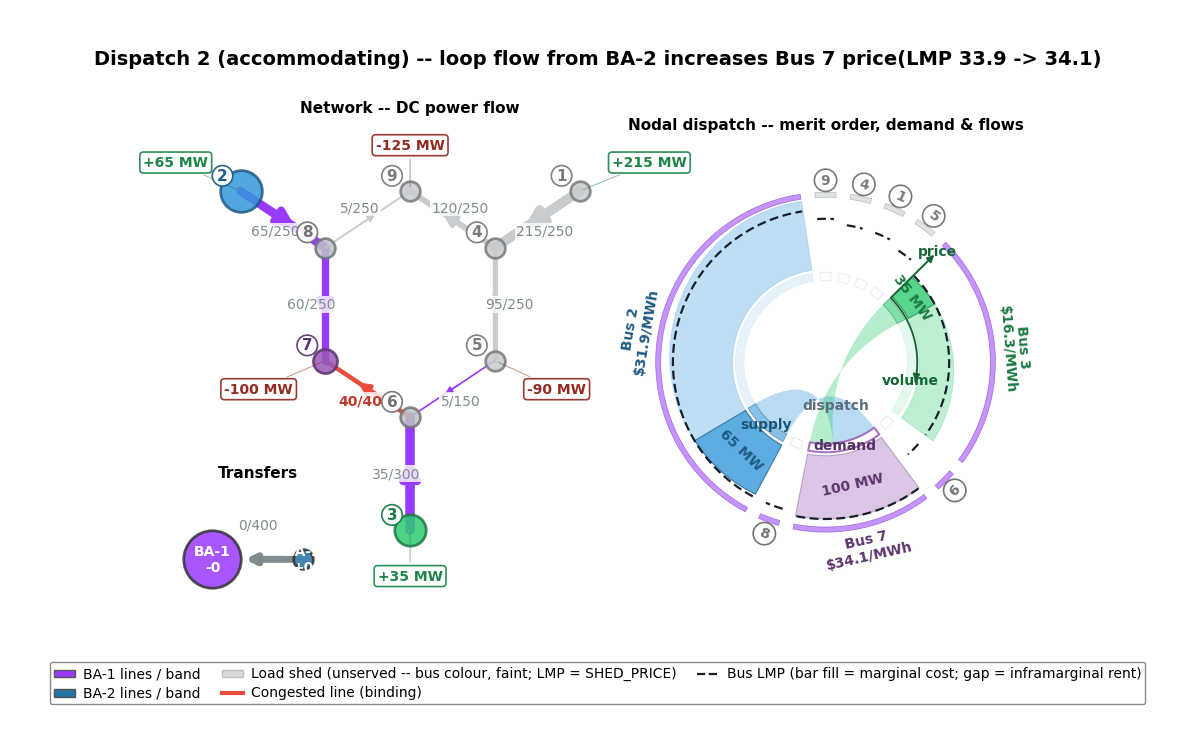

Dispatch 2 (accommodating) -- settlement by node:

,LMP ($/MWh),gen (MW),paid to gen ($/h),load (MW),paid by load ($/h)
bus,,,,,
2,31.85,65.2,2076.2,0.0,0.0
8,31.85,0.0,0.0,0.0,0.0
7,34.06,0.0,0.0,100.0,3406.2
6,16.25,0.0,0.0,0.0,0.0
3,16.25,34.8,565.9,0.0,0.0
SUBTOTAL,,100.0,2642.1,100.0,3406.2
Total - congestion rent,,,,,764.1


Dispatch 2 (accommodating) -- marginal value of line capacity (shadow price x flow, TOTAL = congestion rent):

,from,to,flow (MW),rating (MW),binding,|mu| ($/MWh = value of +1 MW),rent |mu| x flow ($/h)
line,,,,,,,
line_0,1,4,215.0,250.0,False,0.0,0.0
line_1,4,5,95.2,250.0,False,0.0,0.0
line_2,5,6,5.2,150.0,False,0.0,0.0
line_3,3,6,34.8,300.0,False,0.0,0.0
line_4,6,7,40.0,40.0,True,20.9,836.2
line_5,7,8,-60.0,250.0,False,0.0,0.0
line_6,8,2,-65.2,250.0,False,0.0,0.0
line_7,8,9,5.2,250.0,False,0.0,0.0
line_8,9,4,-119.8,250.0,False,0.0,0.0


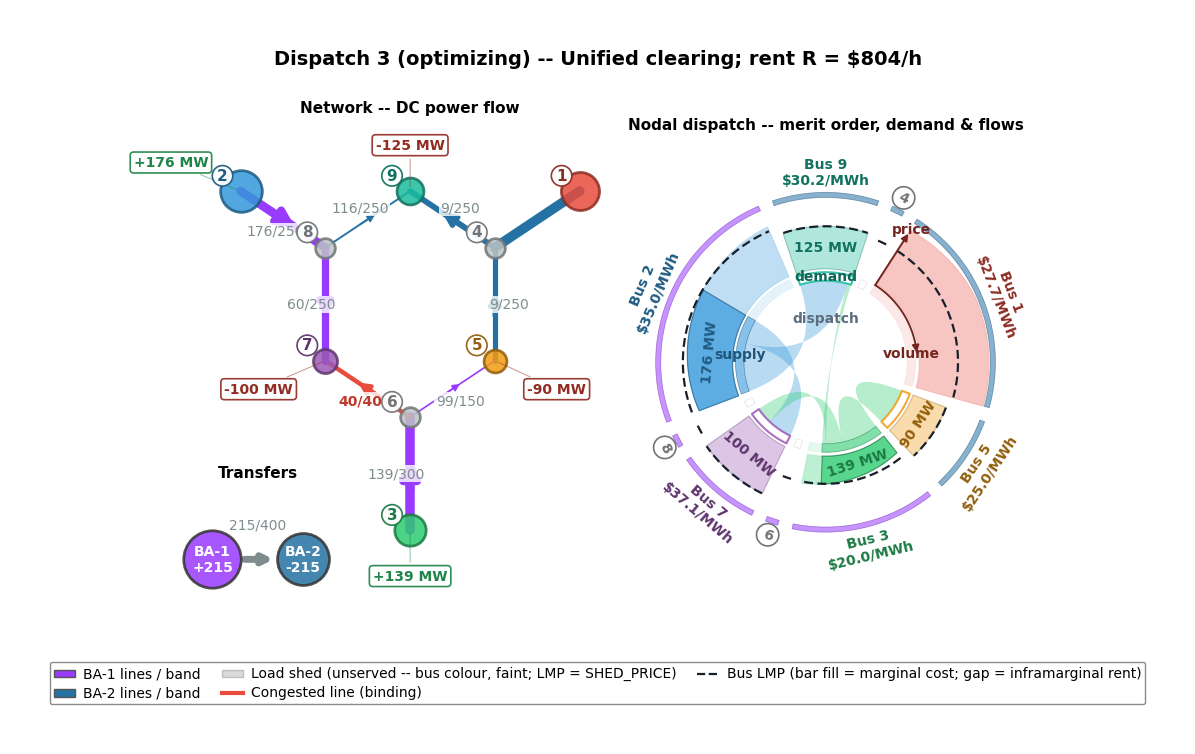

Dispatch 3 (optimizing) -- settlement by node:

,LMP ($/MWh),gen (MW),paid to gen ($/h),load (MW),paid by load ($/h)
bus,,,,,
1,27.74,0.0,0.0,0.0,0.0
2,35.0,176.1,6162.4,0.0,0.0
3,20.0,138.9,2778.6,0.0,0.0
4,27.74,0.0,0.0,0.0,0.0
5,25.02,0.0,0.0,90.0,2251.8
6,20.0,0.0,0.0,0.0,0.0
7,37.13,0.0,0.0,100.0,3712.6
8,35.0,0.0,0.0,0.0,0.0
9,30.25,0.0,0.0,125.0,3780.8


Dispatch 3 (optimizing) -- marginal value of line capacity (shadow price x flow, TOTAL = congestion rent):

,from,to,flow (MW),rating (MW),binding,|mu| ($/MWh = value of +1 MW),rent |mu| x flow ($/h)
line,,,,,,,
line_0,1,4,0.0,250.0,False,0.0,0.0
line_1,4,5,-8.9,250.0,False,0.0,0.0
line_2,5,6,-98.9,150.0,False,0.0,0.0
line_3,3,6,138.9,300.0,False,0.0,0.0
line_4,6,7,40.0,40.0,True,20.1,804.1
line_5,7,8,-60.0,250.0,False,0.0,0.0
line_6,8,2,-176.1,250.0,False,0.0,0.0
line_7,8,9,116.1,250.0,False,0.0,0.0
line_8,9,4,-8.9,250.0,False,0.0,0.0


rising-curve figures

written to C:\Users\docke\Projects\wscc9-illustrative-models\notes\status_quo_merchandising\figures

In [11]:
# The three combined views with rising curves -> *_lin.png (new names; the flat PNGs are
# left untouched so the lab note keeps using them until you swap the includes). For the
# dispatch ring, each unit is drawn as a sloped WEDGE under its rising MC curve.
import os as _os
_OUTL = _os.path.abspath(_os.path.join('notes', 'status_quo_merchandising', 'figures'))
def _expL(fig, name):
    if _os.path.isdir(_OUTL): fig.savefig(_os.path.join(_OUTL, name), dpi=600, bbox_inches='tight')

def _ring_engine(name, buses, res):
    e = make_engine(name, buses=buses)
    for g in e.gens:                                       # attach the curve -> drawn as a sloped wedge
        if g in CURVES:
            e.gens[g]['curve'] = CURVES[g]
    return e

SPECL = [
    ('BA-1', BA_DEFS['BA-1'], res1q, 'BA-1', 'fig_island_lin.png',
     'Dispatch 1 (ignoring) -- Line 6->7 binds at 40 MW'),
    ('BA-1', BA_DEFS['BA-1'], res2q, 'BA-1', 'fig_neighbour_lin.png',
     f"Dispatch 2 (accommodating) -- loop flow from BA-2 increases Bus 7 price"
     f"(LMP {res1q.lmp['7']:.1f} -> {res2q.lmp['7']:.1f})"),
    (None,  ptD.buses,       res3q, None,   'fig_unified_lin.png',
     f'Dispatch 3 (optimizing) -- Unified clearing; rent R = ${R3:,.0f}/h'),
]
# Same two ledgers as the Section-1 unified clearing, printed under each dispatch figure:
# settlement by node (its 'Total - congestion rent' row = load pays minus gen paid) and the
# marginal value of line capacity (|shadow price| x flow, TOTAL = congestion rent).
from revenue_allocation import settlement_by_bus, capacity_value_by_line
for _name, _buses, _res, _hl, _fn, _title in SPECL:
    _eng = _ring_engine(_name or 'UNIFIED', _buses, _res)
    _f = figs.transfer_figure(netD, ptD, fp, _eng, _res, D_EBAR, D_EBAR,
                              suptitle=_title, node_net_mw=True, highlight=_hl,
                              figsize=CB_SIZE, panel_ratios=CB_RATIOS)
    size_for_print(_f)
    _expL(_f, _fn)
    plt.show()
    _label = _title.split(' -- ')[0]                       # e.g. 'Dispatch 1 (ignoring)'
    _nl = settlement_by_bus(_res, _buses, LOADS_ALL)
    _lp = _nl.loc['SUBTOTAL', 'paid by load ($/h)']; _gp = _nl.loc['SUBTOTAL', 'paid to gen ($/h)']
    _nl.loc['Total - congestion rent'] = ['', '', '', '', round(_lp - _gp, 1)]
    print(f'{_label} -- settlement by node:')
    display(_nl)
    print(f'{_label} -- marginal value of line capacity (shadow price x flow, TOTAL = congestion rent):')
    display(capacity_value_by_line(_res, ptD, ptD.lines))
print('rising-curve figures', 'written to ' + _OUTL if _os.path.isdir(_OUTL) else 'shown (figures folder absent)')

### Letting it go -- the congestion revenue each area collects

Optimising with the neighbour (Dispatch 3) is an efficient way to accommodate each other's network impacts, but raises the question of what to do with the newly collected congestion revenue. The congestion revenue an area $a$ collects on its own nodes, $N^c_a$, solves **two ways**.

Entities with **demand** in the area argue from the **bus-based** form, which shows the load funding the surplus:

$$N^c_a=\sum_{n\in a}\lambda_n d_n-\sum_{n\in a}\lambda_n g_n-\sum_{n\in a}\lambda\,(d_n-g_n).$$

Entities that **own the transmission** carrying the flows argue from the **line-based** form, which shows the value it provides:

$$N^c_a=-\!\!\sum_{m\in\mathcal M^{\mathcal A}_{\mathrm{act}}}\!\!\mu_m\,F^{a}_m,\qquad F^{a}_m=\sum_{n\in a} SF_{n,m}\,\underbrace{(g_n-d_n)}_{\text{gen-to-load}}.$$

They are the same number. The ledger below reads the three dispatches through it: the physical rent the 6--7 line carries, $\mu\bar F$, splits into the part **collected** at each area's nodes ($N^c_a$) and -- in Dispatch 2 -- the part that **leaks as uncollected loop flow**, the transmission BA-2 uses but, in the bilateral world, never pays for.

In [12]:
# === The three-dispatch congestion-rent ledger (rising curves) -> CSV ===
# Exactly the write-up table: BA-1 clears alone in D1 (islanded) and D2 (BA-2 fixed as loop
# flow); BA-2 joins only in the unified D3. Rows split into the physical line rent muF and its
# collected (N^c) / uncollected (loop-flow) parts. Written to CSV to reformat the LaTeX table.
import os
def _Lp2(res, a):  return sum(res.lmp[b] * res.load_by_bus.get(b, 0.0) for b in BA_DEFS[a])
def _Gp2(res, a):  return sum(res.lmp[b] * res.gen_by_bus.get(b, 0.0)  for b in BA_DEFS[a])
def _ncc2(res, a): return sum((res.lmp[b] - res.energy_price) * (res.load_by_bus.get(b, 0.0) - res.gen_by_bus.get(b, 0.0))
                              for b in BA_DEFS[a])
def _muF(res):     return abs(res.line_dual['line_4']) * abs(res.flow_own['line_4'])   # rent the 6-7 line carries
_bl = ''                                                                                # '' -> blank cell (renders as --- in LaTeX)

alloc_ledger = pd.DataFrame(
    {'D1': {'bus-7 LMP ($/MWh)':       round(res1q.lmp['7'], 1),
            'load pays L_a':           round(_Lp2(res1q, 'BA-1')),
            'generation paid G_a':     round(_Gp2(res1q, 'BA-1')),
            'congestion rent R':       round(_ncc2(res1q, 'BA-1')),
            'congestion on 6-7 muF':   round(_muF(res1q)),
            '  collected N^c_a':       round(_ncc2(res1q, 'BA-1')),
            '  uncollected loop flow': round(_muF(res1q) - _ncc2(res1q, 'BA-1'))},
     'D2': {'bus-7 LMP ($/MWh)':       round(res2q.lmp['7'], 1),
            'load pays L_a':           round(_Lp2(res2q, 'BA-1')),
            'generation paid G_a':     round(_Gp2(res2q, 'BA-1')),
            'congestion rent R':       round(_ncc2(res2q, 'BA-1')),
            'congestion on 6-7 muF':   round(_muF(res2q)),
            '  collected N^c_a':       round(_ncc2(res2q, 'BA-1')),
            '  uncollected loop flow': round(_muF(res2q) - _ncc2(res2q, 'BA-1'))},
     'D3 BA-1': {'bus-7 LMP ($/MWh)':       round(res3q.lmp['7'], 1),
            'load pays L_a':           round(_Lp2(res3q, 'BA-1')),
            'generation paid G_a':     round(_Gp2(res3q, 'BA-1')),
            'congestion rent R':       round(_ncc2(res3q, 'BA-1') + _ncc2(res3q, 'BA-2')),
            'congestion on 6-7 muF':   round(_muF(res3q)),
            '  collected N^c_a':       round(_ncc2(res3q, 'BA-1')),
            '  uncollected loop flow': round(_muF(res3q) - _ncc2(res3q, 'BA-1') - _ncc2(res3q, 'BA-2'))},
     'D3 BA-2': {'bus-7 LMP ($/MWh)':       _bl,
            'load pays L_a':           round(_Lp2(res3q, 'BA-2')),
            'generation paid G_a':     round(_Gp2(res3q, 'BA-2')),
            'congestion rent R':       _bl,
            'congestion on 6-7 muF':   _bl,
            '  collected N^c_a':       round(_ncc2(res3q, 'BA-2')),
            '  uncollected loop flow': _bl}},
).reindex(['bus-7 LMP ($/MWh)', 'load pays L_a', 'generation paid G_a', 'congestion rent R',
           'congestion on 6-7 muF', '  collected N^c_a', '  uncollected loop flow'])

_out = os.path.join('notes', 'status_quo_merchandising', 'figures')
_out = _out if os.path.isdir(_out) else '.'
_csv = os.path.join(_out, 'congestion_rent_ledger.csv')
alloc_ledger.to_csv(_csv, encoding='utf-8-sig')                 # BOM so Excel reads the '^' / superscripts fine
print('three-dispatch congestion-rent ledger (rising curves) ->', _csv)
alloc_ledger

three-dispatch congestion-rent ledger (rising curves) ->

notes\status_quo_merchandising\figures\congestion_rent_ledger.csv

,D1,D2,D3 BA-1,D3 BA-2
bus-7 LMP ($/MWh),33.9,34.1,37.1,
load pays L_a,3389.0,3406.0,3713.0,6033
generation paid G_a,2569.0,2642.0,8941.0,0
congestion rent R,820.0,764.0,804.0,
congestion on 6-7 muF,820.0,836.0,804.0,
collected N^c_a,820.0,764.0,735.0,69
uncollected loop flow,0.0,72.0,0.0,


## 4. Two allocation rules

The same rent $R$ from eq.&nbsp;(6), now split between the two BAs. First the per-BA
ledger, then two ways to attribute it — by the wire that hosts the limit, and by each area’s gen-to-load impact — then the two methods — each as an equation with a
plain-language reading.

**Per-BA ledger.** For BA $a$ with buses $\mathcal N_a$:

$$G_a=\sum_{n\in\mathcal N_a}\lambda_n g_n,\qquad
  L_a=\sum_{n\in\mathcal N_a}\lambda_n d_n,\qquad
  N_a=L_a-G_a,\qquad \sum_a N_a=R. \qquad (7)$$

*In words.* $G_a$ is what the BA's **generators are paid**, $L_a$ what its **loads pay**, and
$N_a$ its **net payment into the congestion pool**. The two BAs' net payments sum to the whole
rent $R$ — congestion is a transfer from net-paying areas to net-receiving ones. Buses
outside both BAs — a **non-market area** — settle the same way and join the
sum: they pay or are paid at LMP but are never *allocated* rent, and the
ledgers grow a matching column. (`ba_settlement`: `gen_rev`, `load_pay`,
`net_into_pool`; areas come from `AREAS` in the Section-2 config.)

**Rent by line assignment.** Each line is **assigned** to at most one BA — a
configurable choice (the `BA_LINES` lists), not a consequence of the bus partition.
$\mathcal M_a$ is the set of lines assigned to BA $a$ and $\mathcal M_{\emptyset}$
the unassigned remainder. By default a line with both ends in BA $a$ is assigned
to it; here the two ties are also assigned — `line_2` to BA-1, `line_7` to BA-2 —
so $\mathcal M_{\emptyset}$ is empty:

$$R=R^{\emptyset}+\sum_a R_a,\qquad
  R_a=\!\!\sum_{m\,\in\,\mathcal M_a}\!\!|\mu_m F_m|,\qquad
  R^{\emptyset}=\!\!\sum_{m\,\in\,\mathcal M_{\emptyset}}\!\!|\mu_m F_m|. \qquad (8)$$

*In words.* Split the total rent by **which BA manages the binding line**. A line assigned to
BA $a$ feeds $R_a$; rent on lines assigned to neither BA pools in $R^{\emptyset}$.
(`line_rent_table`, `BA_LINES`.)

**Congestion revenue by area.** Method 1 (below) assigns rent by *which wire hosts the limit*. The alternative asks *whose use of the network created the scarcity*: split the rent by each area's own **gen-to-load** contribution to the binding lines. Area $a$'s net injections load line $m$ by $F^a_m=\sum_{n\in a}SF_{n,m}(g_n-d_n)$, and the congestion revenue attributable to it is

$$N^c_a=-\!\!\sum_{m\in\mathcal M_{\mathrm{act}}}\!\!\mu_m\,F^a_m\;=\;\sum_{n\in a}(\lambda_n-\lambda)(d_n-g_n),\qquad \sum_a N^c_a=R. \qquad (9)$$

*In words.* $N^c_a$ is the scarcity each area's own $\mathrm{gen}\!\to\!\mathrm{load}$ flow prices onto the binding lines — equivalently (bus form, from eq. 4) the price separation its own nodes pay. Both readings are the $N^c_a$ of Section 3: the same number, summing to $R$. Because a constraint *internal* to one BA pulls the *other* BA's prices away through the shift factors, $N^c_a$ can be positive for a BA that manages **no** binding line at all — that is precisely the congestion revenue its load over-paid, and the piece Method 2 returns to it. (`regional_congestion`.)

---

**Method&nbsp;1 — the constraint's home BA keeps its full rent.**

$$A^{(1)}_a=R_a+\tfrac12\,R^{\emptyset}. \qquad (10)$$

*In words.* Each BA banks the **full** $\mu_m\!\cdot\!F_m$ rent of every line **assigned
to it**; rent on unassigned lines is split 50/50 (none arise under the default assignment
here). An **internal** constraint's rent stays home **even when that constraint separated
prices in the other BA** — the rent follows the wire's assignment, not the price impact.
This is the full constraint revenue accruing only to the managing BA's settlement.

**Method&nbsp;2 — each area keeps the congestion revenue its own use creates.**

$$A^{(2)}_a=N^c_a. \qquad (11)$$

*In words.* Give each area the $N^c_a$ of eq. (9) — the share of the rent tied to its own $\mathrm{gen}\!\to\!\mathrm{load}$ impact on the binding constraints, returned to the load that paid it. Both allocations sum to $R$, so Method 2 differs from Method 1 by a single **cross-border rebate**: with $h=\operatorname*{arg\,max}_a N_a$ the **net-payer** BA and $f$ the other, $\tau=N^c_h-A^{(1)}_h$ moves from $f$ to $h$,

$$A^{(2)}_h=A^{(1)}_h+\tau,\qquad A^{(2)}_f=A^{(1)}_f-\tau. $$

so an **internal** constraint's rent no longer stays wholly home: the piece the *other* BA's load over-paid — its $N^c$ — is rebated to it as congestion-revenue rights, and total rent is conserved. (The tie-level price-gap split that separates this congestion piece from any transfer-constraint separation is developed in Section 5.)

---

**Two readings of each BA's outcome** (the bottom row of each ledger, built in `revenue_table` — one table per method):

$$\underbrace{P^{(k)}_a=A^{(k)}_a-N_a}_{\text{area net position}},
  \qquad\qquad
  \underbrace{\tilde L^{(k)}_a=L_a-A^{(k)}_a}_{\text{load cost net of CRR}}. \qquad (12)$$

*In words.* $P^{(k)}_a=0$ means method $k$ makes BA $a$ **whole** — its allocated rent exactly
offsets its net payment into the pool. $\tilde L^{(k)}_a$ is the BA's load bill **after** its
allocated rent is rebated to its own consumers as congestion-revenue rights — the number a
load-serving entity ultimately feels. In the ledgers below each BA's **consumers and
generators sit side by side** (cash out negative, cash in positive — the same
conventions as the accommodation-vs-unified comparison closing this section), and the
bottom row carries both readings at once: the **Area net** column is $P^{(k)}_a$
and the **Consumer** column is $-\tilde L^{(k)}_a$. Comparing that row across the
Method&nbsp;1 and Method&nbsp;2 tables is the whole point of the exercise.

In [13]:
# Methodology — implemented in revenue_allocation.py (edit there to refine the
# allocation rule); bound here to this notebook's footprint `fp`.
ba_settlement            = lambda res, loads: ra.ba_settlement(fp, res, loads)
line_rent_table          = lambda res, pt: ra.line_rent_table(fp, res, pt)
border_separation        = lambda res, pt: ra.border_separation(fp, res, pt)
allocate_congestion_rent = lambda res, pt, loads, **kw: ra.allocate_congestion_rent(fp, res, pt, loads, **kw)
compare_methods          = lambda res, pt, loads: ra.compare_methods(fp, res, pt, loads)
print('methodology bound: ba_settlement, line_rent_table, border_separation, '
      'allocate_congestion_rent, compare_methods  (see revenue_allocation.py)')

methodology bound: ba_settlement, line_rent_table, border_separation, allocate_congestion_rent, compare_methods  (see revenue_allocation.py)

In [14]:
# Presentation helpers — figures from wscc9_figures.py, ledgers from
# revenue_allocation.py; bound to fp.
from revenue_allocation import settlement_by_bus, capacity_value_by_line
revenue_table = lambda res, pt, loads: ra.revenue_table(fp, res, pt, loads)

def example_figure(net, pt, engine, res, **kw):
    return figs.footprint_figure(net, pt, fp, engine, res, **kw)

print('presentation bound: example_figure, revenue_table, settlement_by_bus, capacity_value_by_line')

presentation bound: example_figure, revenue_table, settlement_by_bus, capacity_value_by_line

### The scenario — an *internal* constraint, separation in the *other* BA

Congest a line that
lives entirely inside BA-1 (the exporter). The binding limit both isolates a
price pocket at the BA-1 load behind it **and**, through the shift factors, pulls
**BA-2's prices away from the system price** as generation is redispatched across
the border. As a result, prices separate on both sides even though the binding line is
internal to BA-1 and no tie is overloaded.

- **Method 1** credits all of the rent to **BA-1** (the binding line is assigned
  to it), regardless of where the price separation is felt.
- **Method 2** rebates the cross-border separation rent $\tau$ to whichever BA is
  the **net payer** into the congestion pool — the side whose load over-paid for
  the separation — funded by the other BA.

Whether the net-payer turns out to be BA-1 or BA-2 depends on the constraint; the
cells below report it from the actual settlement rather than assuming it. Edit
`SCN_B` to choose which internal BA-1 line binds and how hard.

In [15]:
# -- EDIT -- the scenario: congest a line INTERNAL to BA-1 (the exporter)
SCN_B = {'line_4': 40.0}          # 6-7, internal to BA-1; throttles the cheap bus-3 delivery
# -------------------------------------------------------------------------
net = build_network(SCN_B); pt = compute_ptdf(net, slack_bus='1')
res = solve_engine_dispatch(pt, make_engine('UNIFIED', buses=pt.buses))

print('LMP by bus:', {b: round(res.lmp[b], 1) for b in pt.buses})
print('  BA-1 LMPs:', {b: round(res.lmp[b], 1) for b in BA_DEFS['BA-1']})
print('  BA-2 LMPs:', {b: round(res.lmp[b], 1) for b in BA_DEFS['BA-2']})
print('binding lines:', {l: round(res.line_dual[l], 1) for l in pt.lines if abs(res.line_dual[l]) > 1e-3},
      '(managed by:', {l: LINE_BA[l] for l in pt.lines if abs(res.line_dual[l]) > 1e-3}, ')')

# Line-level diagnostic: the two bases for the split -- rent by line assignment (Method 1)
# and congestion revenue by area N_a^c (gen-to-load impact on the binding lines, Method 2).
_, summ, lr, sep = compare_methods(res, pt, LOADS_ALL)
print('per-line congestion rent (binding lines) -- Method 1 assigns each line to a BA:')
display(lr[lr.rent > 1e-3].round({'rent': 1}))
print('congestion revenue by area N_a^c = -sum_m mu_m F_m^a (gen-to-load) -- the Method 2 basis:')
display(pd.Series({a: round(summ['Nc'][a], 1) for a in fp.names}, name='N_a^c ($/h)').to_frame().T)
print(f"total rent R = {summ['R']:.1f}  |  by line assignment: BA-1 = {summ['R_own']['BA-1']:.1f}, "
      f"BA-2 = {summ['R_own']['BA-2']:.1f}  |  by gen-to-load N_a^c: BA-1 = {summ['Nc']['BA-1']:.1f}, "
      f"BA-2 = {summ['Nc']['BA-2']:.1f}")
print(f"cross-border rebate tau = {summ['tau']:.1f}  ->  Method 2 moves it from {summ['funding_ba']} to the "
      f"net-payer {summ['hedged_ba']} (the load that over-paid), turning Method 1's split into each BA's N_a^c.")
print('BA-level congestion-revenue ledgers (Method 1 vs Method 2) are in the next cell.')

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


LMP by bus:

{'1': np.float64(27.7), '2': np.float64(35.0), '3': np.float64(20.0), '4': np.float64(27.7), '5': np.float64(25.0), '6': np.float64(20.0), '7': np.float64(37.1), '8': np.float64(35.0), '9': np.float64(30.2)}

  BA-1 LMPs:

{'2': np.float64(35.0), '8': np.float64(35.0), '7': np.float64(37.1), '6': np.float64(20.0), '3': np.float64(20.0)}

...

congestion revenue by area N_a^c = -sum_m mu_m F_m^a (gen-to-load) -- the Method 2 basis:

,BA-1,BA-2
N_a^c ($/h),734.9,69.2


total rent R = 804.1  |  by line assignment: BA-1 = 804.1, BA-2 = 0.0  |  by gen-to-load N_a^c: BA-1 = 734.9, BA-2 = 69.2

cross-border rebate tau = 69.2  ->  Method 2 moves it from BA-1 to the net-payer BA-2 (the load that over-paid), turning Method 1's split into each BA's N_a^c.

BA-level congestion-revenue ledgers (Method 1 vs Method 2) are in the next cell.

**Reading the scenario.** The binding constraint is inside BA-1, so under
**Method 1** BA-1 banks the entire congestion rent simply because its wires host
the limit. **Method 2** instead rebates the cross-border separation $\tau$ to the
BA whose participants were the net payers for that separation, so each BA ends up
holding rent commensurate with the price gap *its own meters* bore rather than the
gap its wires happened to host. The `TOTAL` column is identical under both methods
— the rent is only **reallocated**, never created or destroyed. (The contrast is
sharpest when the constraint's home BA and the net-paying BA differ; tune `SCN_B`
to explore that.)

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


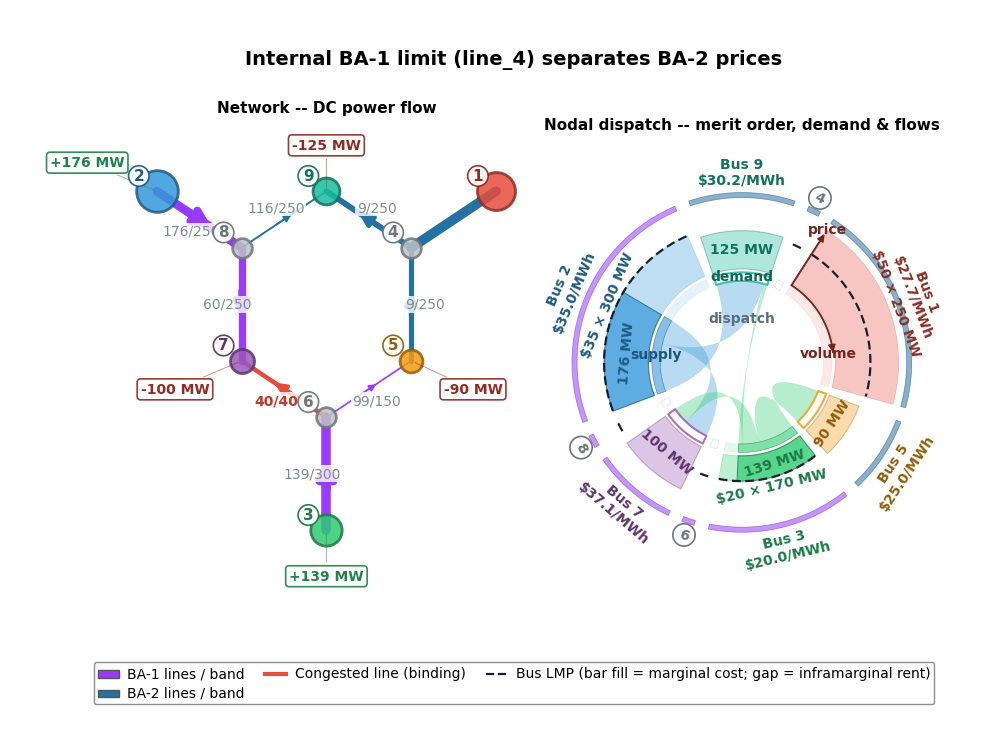

Rent on the internal BA-1 line, R = $804/h; Method 1 banks it in BA-1 (its wires host the limit), Method 2 moves tau = $69/h to net-payer BA-2.

Compare the bottom 'Net position' row: Area net = A - N (0 => made whole); the Consumer

column is the load bill net of CRR, as a cash position (negative = cash out).

Method 1 -- each BA keeps the rent on its assigned lines:

BA-1                        BA-2                     TOTAL
                                     Consumer Generator Area net Consumer Generator Area net       
Energy settlement  (lmp x q)          -3712.6    8941.0   5228.4  -6032.5       0.0  -6032.5 -804.1
Congestion rent allocated  (A)          804.1              804.1      0.0                0.0  804.1
Net position  (Area net: 0 => whole)  -2908.5    8941.0   6032.5  -6032.5       0.0  -6032.5    0.0

Method 2 -- each BA keeps the congestion revenue its gen-to-load creates (N_a^c):

BA-1                        BA-2                     TOTAL
                                     Consumer Generator Area net Consumer Generator Area net       
Energy settlement  (lmp x q)          -3712.6    8941.0   5228.4  -6032.5       0.0  -6032.5 -804.1
Congestion rent allocated  (A)          734.9              734.9     69.2               69.2  804.1
Net position  (Area net: 0 => whole)  -2977.7    8941.0   5963.3  -5963.3       0.0  -5963.3    0.0

In [16]:
# The scenario -- composite figure + homework-style congestion-revenue tables.
net = build_network(SCN_B); pt = compute_ptdf(net, slack_bus='1')
uni = make_engine('UNIFIED', buses=pt.buses); res = solve_engine_dispatch(pt, uni)
fig = example_figure(net, pt, uni, res, node_net_mw=True, figsize=CB_SIZE, panel_ratios=CB_RATIOS,
               suptitle='Internal BA-1 limit (line_4) separates BA-2 prices')
size_for_print(fig)
plt.show()
rtbl1, rtbl2, summ = revenue_table(res, pt, LOADS_ALL)
print(f"Rent on the internal BA-1 line, R = ${summ['R']:.0f}/h; Method 1 banks it "
      f"in BA-1 (its wires host the limit), Method 2 moves tau = ${summ['tau']:.0f}/h to "
      f"net-payer {summ['hedged_ba']}.")
print("Compare the bottom 'Net position' row: Area net = A - N (0 => made whole); the Consumer")
print("column is the load bill net of CRR, as a cash position (negative = cash out).")
print("Method 1 -- each BA keeps the rent on its assigned lines:")
display(rtbl1)
print("Method 2 -- each BA keeps the congestion revenue its gen-to-load creates (N_a^c):")
display(rtbl2)

### Unified vs independent operation — the two-engine counterfactual

The cross-border separation exists only because a **single co-optimised clearing**
prices every bus against *all* constraints at once. The counterfactual is
**independent operation**: each BA runs as its own *independent engine* on the
same full 9-bus network — serving its own load from its own generators and
enforcing **only the lines assigned to it** (`LINE_BA`: its internal lines plus
its assigned tie), with every other line left unconstrained (a nodal DC-OPF per
BA, not a copperplate). No interchange is scheduled.

Two things surface:

1. On the **base network** each BA clears at its own price.
2. On the **scenario network**, BA-1's internal `line_4` limit splits prices
   *within* BA-1 and, through the shift factors, moves BA-2's prices too. Under
   the **unified clearing** the same constraint is co-optimised against the border,
   and the resulting cross-border price separation is the congestion rent that then
   has to be allocated.

**The baseline for the Pareto check below is not this full independence, but the *accommodation* case of Dispatch 2** — BA-2's net injections placed on the grid as exogenous inputs, with BA-1 redispatching to absorb the loop flow they add to `line_4`. Independent operation isolates the price gap; accommodation is the realistic status quo BA-1 already lives in — it carries the neighbour's flow today, just unpriced — so it is the counterfactual against which *pricing* that flow (the unified clearing) is judged.

In [17]:
# Independent operation: each BA as its own engine on the full network
# (revenue_allocation.independent_clear), bound to fp.
independent_clear = lambda rat, shed_price=None: ra.independent_clear(fp, rat, shed_price=shed_price)

# (a) Base network -- both BAs self-serve; the price gap is what motivates trade.
_, base = independent_clear({})
print('independent prices on the BASE network:',
      {ba: (f"${base[ba].energy_price:.0f}" if base[ba] else 'INFEASIBLE') for ba in BA_DEFS})

# (b) Scenario network -- the internal BA-1 limit as the counterfactual stress.
ptB, indep = independent_clear(SCN_B)
resU = solve_engine_dispatch(ptB, make_engine('UNIFIED', buses=ptB.buses))
cmp = pd.DataFrame({b: {
    'BA': ba_of(b),
    'independent LMP': (round(indep[ba_of(b)].lmp[b], 1) if indep[ba_of(b)] else float('nan')),
    'unified LMP (scenario)': round(resU.lmp[b], 1),
} for b in ptB.buses}).T
display(cmp)
for ba in BA_DEFS:
    if indep[ba] is None:
        print(f'{ba} is INFEASIBLE on its own: with the line_4 limit and only its own '
              f'generation it cannot serve its load -- it depends on imports across the '
              f'border. That dependence is what the unified clearing prices, and what the '
              f'congestion-revenue allocation then divides.')
    else:
        gap = max(indep[ba].lmp[b] for b in BA_DEFS[ba]) - min(indep[ba].lmp[b] for b in BA_DEFS[ba])
        print(f'{ba} independent: clears feasibly, internal price spread ${gap:.1f}/MWh.')

# --- the ACCOMMODATION baseline (the status quo the Pareto ledgers measure against) ---------
# BA-2's autarky net-injection pattern (its dear bus-1 unit serving its own 5/9 load) is placed
# on the grid as fixed EXOGENOUS inputs, and BA-1 accommodates the loop flow they add to its
# lines. This 'Autarky Accommodation' is Dispatch 2 -- more realistic than full independence.
BA2_EXO = {'1': sum(LOADS_ALL[b] for b in BA_DEFS['BA-2'] if b in LOADS_ALL),
           '5': -LOADS_ALL['5'], '9': -LOADS_ALL['9']}
def accommodation_baseline(ratings):
    """Per-area baseline on the given ratings: BA-1 clears with BA-2's autarky injections fixed
    exogenous (accommodating their loop flow); BA-2 self-serves. Returns {area: EngineResult}."""
    _pt = compute_ptdf(build_network(ratings), slack_bus='1')
    _, _ind = independent_clear(ratings, shed_price=SHED_PRICE)
    _a1 = [l for l in _pt.lines if LINE_BA.get(l) == 'BA-1']
    _r1 = solve_engine_dispatch(_pt, make_engine('BA-1', BA_DEFS['BA-1'], activated=_a1),
                                exo=BA2_EXO, shed_price=SHED_PRICE)
    return {'BA-1': _r1, 'BA-2': _ind['BA-2']}
# rename an autarky-vs-* ledger's baseline rows to the 'Autarky Accommodation' label
relabel_accom = lambda t: t.rename(index=lambda s: s.replace('Autarky', 'Autarky Accommodation').replace('autarky', 'autarky accommodation'))

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


independent prices on the BASE network:

{'BA-1': '$20', 'BA-2': '$50'}

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


,BA,independent LMP,unified LMP (scenario)
1,BA-2,50.0,27.7
2,BA-1,35.0,35.0
3,BA-1,20.0,20.0
4,BA-2,50.0,27.7
5,BA-2,50.0,25.0
6,BA-1,20.0,20.0
7,BA-1,37.1,37.1
8,BA-1,35.0,35.0
9,BA-2,50.0,30.2


BA-1 independent: clears feasibly, internal price spread $17.1/MWh.

BA-2 independent: clears feasibly, internal price spread $0.0/MWh.

### The two-BA dispatch, per BA (other BA greyed)

The **Autarky Accommodation** baseline drawn per BA as a combined network + nodal-merit chart, the other BA's nodes greyed. BA-1 accommodates BA-2's exogenous injections -- the loop flow they add to `line_4` -- while BA-2 self-serves at its own autarky prices. This is the baseline the Pareto ledger below measures the unified clearing against.

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


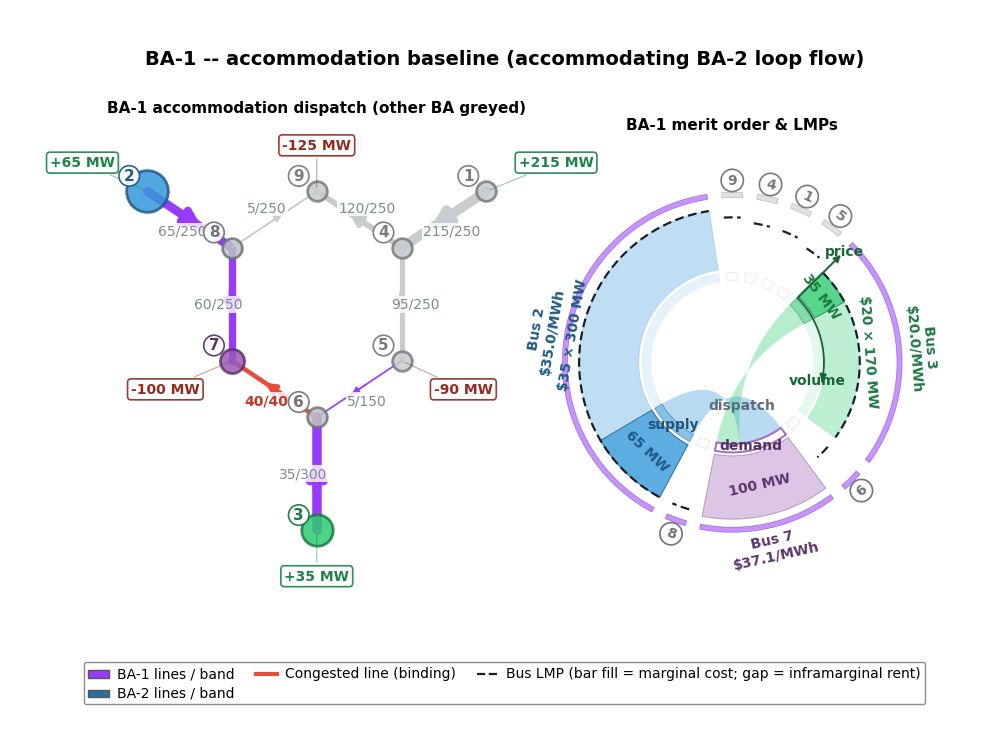

BA-1 (accommodating BA-2 loop flow): energy $28/MWh; own-bus LMPs {'2': np.float64(35.0), '8': np.float64(35.0), '7': np.float64(37.1), '6': np.float64(20.0), '3': np.float64(20.0)}

BA-1 -- settlement by node (accommodation baseline):

,LMP ($/MWh),gen (MW),paid to gen ($/h),load (MW),paid by load ($/h)
bus,,,,,
2,35.0,65.2,2281.4,0.0,0.0
8,35.0,0.0,0.0,0.0,0.0
7,37.13,0.0,0.0,100.0,3712.6
6,20.0,0.0,0.0,0.0,0.0
3,20.0,34.8,696.3,0.0,0.0
SUBTOTAL,,100.0,2977.7,100.0,3712.6


BA-1 -- marginal value of its assigned lines (shadow price x flow):

,from,to,flow (MW),rating (MW),binding,|mu| ($/MWh = value of +1 MW),rent |mu| x flow ($/h)
line,,,,,,,
line_2,5,6,5.2,150.0,False,0.0,0.0
line_3,3,6,34.8,300.0,False,0.0,0.0
line_4,6,7,40.0,40.0,True,20.1,804.1
line_5,7,8,-60.0,250.0,False,0.0,0.0
line_6,8,2,-65.2,250.0,False,0.0,0.0
TOTAL,,,,,,,804.1


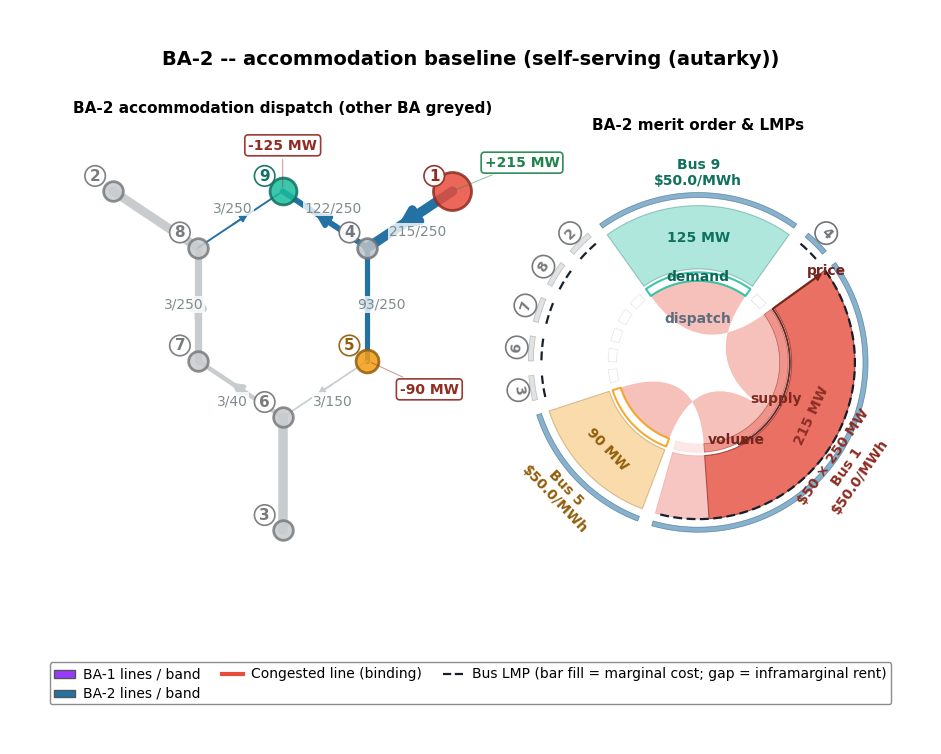

BA-2 (self-serving (autarky)): energy $50/MWh; own-bus LMPs {'1': np.float64(50.0), '9': np.float64(50.0), '4': np.float64(50.0), '5': np.float64(50.0)}

BA-2 -- settlement by node (accommodation baseline):

,LMP ($/MWh),gen (MW),paid to gen ($/h),load (MW),paid by load ($/h)
bus,,,,,
1,50.0,215.0,10750.0,0.0,0.0
9,50.0,0.0,0.0,125.0,6250.0
4,50.0,0.0,0.0,0.0,0.0
5,50.0,0.0,0.0,90.0,4500.0
SUBTOTAL,,215.0,10750.0,215.0,10750.0


BA-2 -- marginal value of its assigned lines (shadow price x flow):

,from,to,flow (MW),rating (MW),binding,|mu| ($/MWh = value of +1 MW),rent |mu| x flow ($/h)
line,,,,,,,
line_0,1,4,215.0,250.0,False,0.0,0.0
line_1,4,5,93.4,250.0,False,0.0,0.0
line_7,8,9,3.4,250.0,False,0.0,0.0
line_8,9,4,-121.6,250.0,False,0.0,0.0
TOTAL,,,,,,,0.0


In [18]:
# Per-BA composite of the ACCOMMODATION baseline (scenario network), the other BA greyed:
# BA-1 clears with BA-2's autarky injections fixed exogenous (accommodating the loop flow they
# add to line_4); BA-2 self-serves. This is the 'Autarky Accommodation' baseline of the ledger.
netB = build_network(SCN_B); ptB = compute_ptdf(netB, slack_bus='1')
for ba in BA_DEFS:
    act = [l for l in ptB.lines if LINE_BA.get(l) == ba]
    eng = make_engine(ba, BA_DEFS[ba], activated=act)
    r = solve_engine_dispatch(ptB, eng, exo=(BA2_EXO if ba == 'BA-1' else None), shed_price=SHED_PRICE)
    other = [b for b in ptB.buses if ba_of(b) != ba]
    _role = 'accommodating BA-2 loop flow' if ba == 'BA-1' else 'self-serving (autarky)'
    fig = example_figure(netB, ptB, eng, r, dim_buses=other, node_net_mw=True, figsize=CB_SIZE, panel_ratios=CB_RATIOS,
                   title_left=f'{ba} accommodation dispatch (other BA greyed)',
                   title_right=f'{ba} merit order & LMPs',
                   suptitle=f'{ba} -- accommodation baseline ({_role})')
    size_for_print(fig)
    plt.show()
    print(f"{ba} ({_role}): energy ${r.energy_price:.0f}/MWh; own-bus LMPs "
          f"{ {b: round(r.lmp[b], 1) for b in BA_DEFS[ba]} }")
    print(f'{ba} -- settlement by node (accommodation baseline):')
    display(settlement_by_bus(r, BA_DEFS[ba], LOADS_ALL))
    print(f'{ba} -- marginal value of its assigned lines (shadow price x flow):')
    display(capacity_value_by_line(r, ptB, act))

### Accommodation vs unified -- the gains from trade and who captures them

Each BA's **consumer** and **generator** position under the **accommodation** baseline
(Dispatch 2 -- BA-2's net injections are treated as exogenous inputs and BA-1 accommodates the
loop flow they add to its lines, bearing the redispatch cost unpriced) versus the **unified**
clearing, with the congestion rent rebated to consumers as congestion-revenue rights (CRR).
Accommodation is the right baseline because it is the **status quo**: BA-1 already carries the
neighbour's loop flow today, just without a settlement for it. 

Conventions: consumer payments are negative (cash out), generator revenue positive (cash
in); a BA's generator **position** is producer surplus (revenue minus production cost),
and its **final** consumer position is the load bill net of the CRR rebate. **The accommodation baseline also
rebates each BA's own internal congestion rent to its own consumers** -- the same CRR
treatment as the unified case -- so the comparison is like-for-like and the change versus
accommodation isolates the gains from trade plus the cross-border reallocation, which drives the
Pareto check.

*Note on this fleet:* with one unit per bus each generator sets its own bus price, so
producer surplus is ~0 everywhere and the entire price wedge is congestion rent -- all
the distributional action sits on the consumer / CRR side. That degeneracy lifts once the
fleet becomes a real supply mix (a baseload block plus a sloped mid-merit/peaking ramp),
at which point the generator columns carry genuine inframarginal rent and the same ledger
keeps working unchanged. (This is a planned future enhancement.)

In [19]:
# Accommodation vs unified, homework-style -- one table per allocation method, with the
# congestion-revenue derivation folded into the Unified block:
#   R (system)  ->  N_a^c (congestion by region)  ->  Congestion Revenue Allocation.
netB = build_network(SCN_B); ptB = compute_ptdf(netB, slack_bus='1')
resU = solve_engine_dispatch(ptB, make_engine('UNIFIED', buses=ptB.buses))
alloc, summ, _, _ = allocate_congestion_rent(resU, ptB, LOADS_ALL)
COST = ra.cost_by_bus(GEN_FLEET)                          # bus -> marginal cost

# Baseline = the ACCOMMODATION case (Dispatch 2, not full independence): BA-2's autarky net
# injections are exogenous, and BA-1 accommodates the loop flow they add to line_4 -- bearing
# the redispatch cost unpriced. That is the 'Autarky Accommodation' status quo the unified
# clearing is measured against (same baseline as the per-BA graphics above).
accom = accommodation_baseline(SCN_B)                      # {'BA-1': accommodating, 'BA-2': autarky}

_agg = lambda result, area: ra._agg(fp, result, area, LOADS_ALL, COST)
ledger = lambda method: relabel_accom(ra.autarky_vs_unified_congestion(fp, method, alloc, accom, resU,
                                                                       ptB, loads=LOADS_ALL, cost=COST))

pc_acc = sum(_agg(accom[ba], ba)[2] for ba in AREAS)
pc_uni = sum(_agg(resU, ba)[2] for ba in AREAS)
print(f"System production cost: accommodation ${pc_acc:,.0f}/h  ->  unified ${pc_uni:,.0f}/h  "
      f"(gains from trade ${pc_acc - pc_uni:,.0f}/h);  congestion rent R = ${summ['R']:.0f}/h.")
print("Baseline = the accommodation case (Dispatch 2): BA-2's injections are exogenous and BA-1 bears the")
print("loop-flow redispatch unpriced. Both baseline and unified rebate each BA's own internal congestion")
print("rent to its consumers, so Delta-vs-accommodation isolates the gains from trade plus the cross-border")
print("reallocation the unified clearing prices -- which drives the Pareto check.")
print("The Unified block shows R splitting into N_a^c (what each BA's prices create) vs the")
print("Congestion Revenue Allocation each method gives it -- N_a^c is identical across methods.")
print()
print("Method 1 -- each BA keeps the rent on its assigned lines:")
display(ledger(1))
print("Method 2 -- each BA keeps the congestion revenue its gen-to-load creates (= N_a^c):")
display(ledger(2))

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


System production cost: accommodation $13,728/h  ->  unified $8,941/h  (gains from trade $4,787/h);  congestion rent R = $804/h.

Baseline = the accommodation case (Dispatch 2): BA-2's injections are exogenous and BA-1 bears the

...

Congestion Revenue Allocation each method gives it -- N_a^c is identical across methods.

Method 1 -- each BA keeps the rent on its assigned lines:

BA-1               BA-2              TOTAL
                                                 Consumer Generator Consumer Generator         
Autarky Accommodation: payment / revenue          -3712.6    2977.7 -10750.0   10750.0   -734.9
Autarky Accommodation: production cost                      -2977.7           -10750.0 -13727.7
Autarky Accommodation: own congestion rent (CRR)    734.9                0.0              734.9
Autarky Accommodation: position                   -2977.7       0.0 -10750.0       0.0 -13727.7
Unified: payment / revenue                        -3712.6    8941.0  -6032.5       0.0   -804.1
Unified: production cost                                    -8941.0               -0.0  -8941.0
Unified: congestion rent -- system (R)                                                    804.1
Unified: congestion by region (N_a^c)               734.9               69.2              804.1
Unified: Congestion Revenue Allocation              804.1                0.0              804.1
Final position                                    -2908.5       0.0  -6032.5       0.0  -8941.0
Delta vs autarky accommodation                       69.2       0.0   4717.5       0.0   4786.7
Pareto (Delta >= 0)                                   yes       yes      yes       yes

Method 2 -- each BA keeps the congestion revenue its gen-to-load creates (= N_a^c):

BA-1               BA-2              TOTAL
                                                 Consumer Generator Consumer Generator         
Autarky Accommodation: payment / revenue          -3712.6    2977.7 -10750.0   10750.0   -734.9
Autarky Accommodation: production cost                      -2977.7           -10750.0 -13727.7
Autarky Accommodation: own congestion rent (CRR)    734.9                0.0              734.9
Autarky Accommodation: position                   -2977.7       0.0 -10750.0       0.0 -13727.7
Unified: payment / revenue                        -3712.6    8941.0  -6032.5       0.0   -804.1
Unified: production cost                                    -8941.0               -0.0  -8941.0
Unified: congestion rent -- system (R)                                                    804.1
Unified: congestion by region (N_a^c)               734.9               69.2              804.1
Unified: Congestion Revenue Allocation              734.9               69.2              804.1
Final position                                    -2977.7       0.0  -5963.3       0.0  -8941.0
Delta vs autarky accommodation                        0.0       0.0   4786.7       0.0   4786.7
Pareto (Delta >= 0)                                   yes       yes      yes       yes

## 5. Optimized transfers

Transfers between balancing authority areas in the market footprint are
optimized. The market enforces a **scheduling limit** on the net interchange
between the footprints: in EDAM, a transfer is modelled as a matching
export/import pair between two balancing authorities, each BAA's **net
transfer** enters its own power balance, and the scheduling limits are
enforced beside the line limits, under the same generalized network
constraint index. In concept, the transfers are a transport layer on top of
the nodal network layer.

This section adds that transport-layer constraint to the nodal dispatch
developed above: a single limit $\bar E$ on the **net energy interchange** $E$
between BA-1 and BA-2. Its natural ceiling is the **combined rating of the
ties** that physically connect the BAs (`line_2` + `line_7`) — a limit above
that can never bind, because the tie flows already cap the interchange.




### The transfer constraint at work

Section 1 already placed the transfer limit in the clearing problem (eq. 2), the Lagrangian (eq. 3), and the price (eq. 4): every BA-1 bus carries the same extra term $\mathbb 1\{n\in\mathcal N_1\}\,\mu_T$, so with no line binding, prices are **flat within each BA and differ between them by $|\mu_T|$** — the EDAM structure, each BAA its own power-balance dual linked by the scheduled transfer. (With the slack bus in BA-2, $\mu_T<0$ when BA-1's export cap binds: the exporter's prices sit $|\mu_T|$ *below* the importer's.) This section develops the interchange $E$ and settles its rent.

**Nomenclature (new here).**

| Symbol | Definition |
|---|---|
| $a$, $\mathcal N_a$ | a balancing authority and its bus set (Section 2); $\mathcal N_1$ is BA-1's |
| $\mathcal M^{\mathrm{tie}}$ | the ties — lines whose ends sit in different BAs (Section 2) |
| $\partial\mathcal N_1$ | BA-1's boundary — lines with exactly one end in $\mathcal N_1$ ($=\mathcal M^{\mathrm{tie}}$ when the BAs cover every bus) — eq. (13) |
| $E,\ \bar E$ | net energy interchange out of BA-1 (export positive) and its transfer (scheduling) limit (`TRANSFER_LIMIT`/`XFER_BIND`) — eq. (13) |
| $s_m$ | boundary orientation: $+1$ if line $m$'s from-bus is in $\mathcal N_1$, else $-1$ — eq. (13) |
| $\mu_T,\ R_T$ | the transfer constraint's (signed) shadow price and the transfer rent $\lvert\mu_T E\rvert$ (eqs. 4, 6) |
| $\sigma_a,\ A^T_a$ | BA $a$'s share of the transfer rent ($\sum_a\sigma_a=1$) and its allocation $A^T_a=\sigma_a R_T$ — eq. (14) |

**The interchange, two readings.** Writing $\mathcal N_1$ for BA-1's bus set, its net interchange is whatever its generators produce beyond its own served load — and, losslessly, whatever leaves over its boundary:

$$E=\sum_{i:\,\mathrm{bus}(i)\in\mathcal N_1} g_i-\sum_{n\in\mathcal N_1} d_n\;=\;\sum_{m\,\in\,\partial\mathcal N_1} s_m\,F_m,\qquad s_m=\begin{cases}+1 & \text{line $m$'s from-bus}\in\mathcal N_1,\\ -1 & \text{otherwise.}\end{cases}\qquad(13)$$

*In words.* $\partial\mathcal N_1$ is BA-1's **boundary** — every line with exactly one end inside $\mathcal N_1$. Lossless DC gives the second equality for free: every megawatt BA-1 does not consume must leave over its boundary, so the *scheduled* interchange and the *summed physical boundary flow* are one number read two ways. Here the two BAs cover every bus, so $\partial\mathcal N_1=\mathcal M^{\mathrm{tie}}$; with a **non-market area** the boundary also counts BA-1's lines into it, while $\mathcal M^{\mathrm{tie}}$ — and the tie price-gap split (`border_separation`) built on it — stays the BA-to-BA border.

**Transfer rent and its allocation.** The transfer rent $R_T=\lvert\mu_T E\rvert$ (eq. 6) is a **separate revenue stream** from the congestion rent $R$: the revenue identity (eq. 5) splits what load pays minus what generation receives into $R$ (line congestion) plus $R_T$ (the border price gap times the megawatts crossing). Whenever the schedule binds, $R_T$ is allocated by a configurable transfer methodology — the $\sigma_a$ of the `allocate_transfer_rent` block:

$$A^T_a=\sigma_a\,R_T,\qquad \sum_a\sigma_a=1\qquad(\textbf{T1}:\ \text{fixed \texttt{TRANSFER\_SPLIT} shares};\quad \textbf{T2}:\ \text{all to the net-payer BA}).\qquad(14)$$

*In words.* The optimisation fixes $R_T$ itself — the constraint and its dual price the schedule — but not who receives it: the split is a settlement rule chosen outside the dispatch (EDAM shares transfer revenue equally between the two BAAs), written here so it can be refined. The Methods 1 and 2 of Section 4 apply to the congestion rent $R$ only, and because the congestion rent is priced through the **line** multipliers $\mu_m$ (eq. 9), the separation the schedule creates is settled exactly once — as $R_T$ — and never re-enters the Method-2 rebate. The transfer row is identical in both ledgers.

In [20]:
# -- EDIT -- the transfer (interchange scheduling) limit ---------------------
TIE_CAP = float(sum(pt.s_nom[pt.line_idx[l]] for l in ties))   # combined tie rating: the physical envelope
TRANSFER_LIMIT = TIE_CAP    # Ebar; lower it below TIE_CAP to make the SCHEDULE bind
# -- EDIT -- allocation methodologies for the two revenue streams -------------
CONGESTION_METHODS = [1, 2]                   # congestion rules to tabulate (one ledger each)
TRANSFER_METHODS   = [1, 2]                   # transfer rules: 1 = fixed shares, 2 = net-payer
TRANSFER_SPLIT = {'BA-1': 0.5, 'BA-2': 0.5}   # Method T1's shares sigma_a (EDAM: equal split)
# ----------------------------------------------------------------------------
assert set(TRANSFER_SPLIT) == set(BA_DEFS) and abs(sum(TRANSFER_SPLIT.values()) - 1.0) < 1e-9, \
    'TRANSFER_SPLIT must cover both BAs and sum to 1'
T_NAMES = ra.T_NAMES

# Transfer model — implemented in revenue_allocation.py / wscc9_figures.py; bound to fp.
transfer_rent          = ra.transfer_rent
allocate_transfer_rent = lambda res, loads, t_method: ra.allocate_transfer_rent(fp, res, loads, t_method, TRANSFER_SPLIT)
solve_with_transfer    = lambda ratings, ebar: ra.solve_with_transfer(fp, ratings, ebar, shed_price=SHED_PRICE)
transfer_ledger        = lambda res, p, loads, method, t_method, indep: \
    ra.transfer_ledger(fp, res, p, loads, method, t_method, indep, TRANSFER_SPLIT)

def draw_net_dispatch(ax, res, ebar, engine):
    return figs.draw_net_dispatch(ax, fp, res, ebar, engine, TIE_CAP)

def transfer_figure(n, p, e, r, ebar, suptitle=None):
    return figs.transfer_figure(n, p, fp, e, r, ebar, TIE_CAP, suptitle=suptitle, node_net_mw=True,
                                figsize=CB_SIZE, panel_ratios=CB_RATIOS)

print(f'transfer model bound: TIE_CAP = {TIE_CAP:.0f} MW (combined tie rating);  '
      f'TRANSFER_LIMIT = {TRANSFER_LIMIT:.0f} MW')
print('allocation knobs: CONGESTION_METHODS = ' + str(CONGESTION_METHODS)
      + ',  TRANSFER_METHODS = ' + str(TRANSFER_METHODS) + ' (T1 shares: '
      + ' / '.join(f'{ba} {TRANSFER_SPLIT[ba]:.0%}' for ba in BA_DEFS) + ')')

transfer model bound: TIE_CAP = 400 MW (combined tie rating);  TRANSFER_LIMIT = 400 MW

allocation knobs: CONGESTION_METHODS = [1, 2],  TRANSFER_METHODS = [1, 2] (T1 shares: BA-1 50% / BA-2 50%)

*Reading the figures below.* Each figure gains a small **Transfers** inset
in the lower left of the network panel, drawn to the network diagram's own
visual conventions: each BA collapses to one bubble **sized like the network's
bus bubbles** (generation capacity plus load — the BA's total addressable
market) and labelled with its **net surplus**; the connecting line carries the
interchange as a `flow/limit` label, exactly like a line's `flow/rating`, and
its **width is the transfer limit** $\bar E$ relative to the combined tie
rating — a thin line is a tight tie. When the constraint binds the line turns
**red**, the label sits at its limit (`120/120`), and the transfer shadow
price $|\mu_T|$ appears below it as a price label.

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


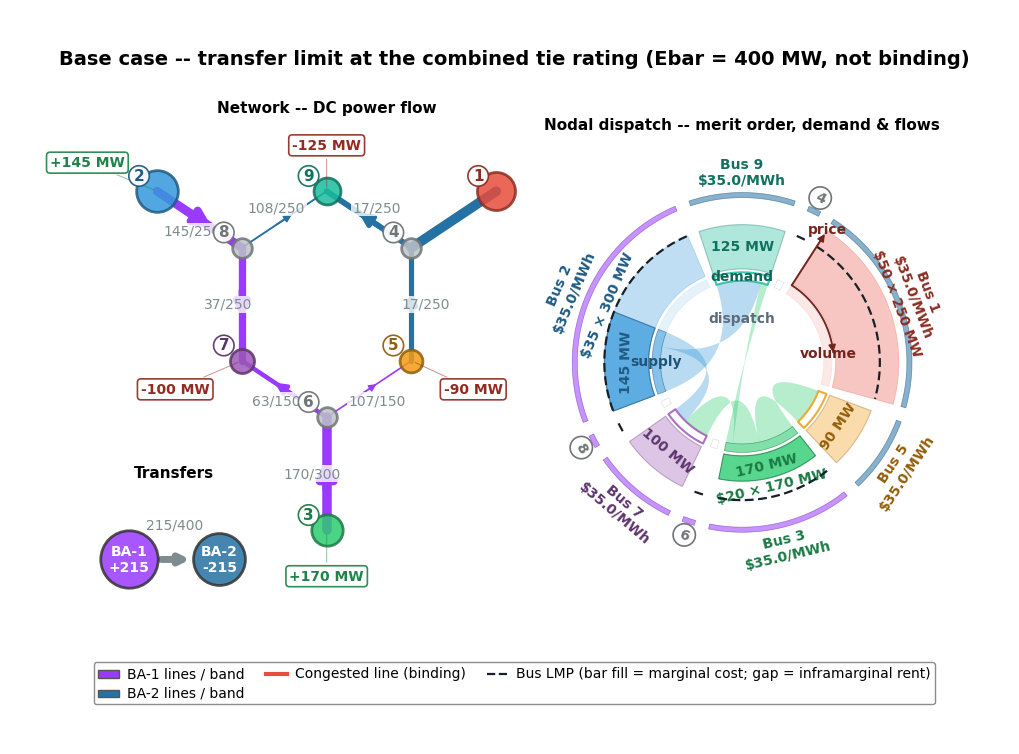

interchange E = 215.0 MW of Ebar = 400 MW  ->  mu_T = 0.00  (not binding)

LMP by bus:

{'1': np.float64(35.0), '2': np.float64(35.0), '3': np.float64(35.0), '4': np.float64(35.0), '5': np.float64(35.0), '6': np.float64(35.0), '7': np.float64(35.0), '8': np.float64(35.0), '9': np.float64(35.0)}

Identical to the unconstrained base clearing: at the physical envelope the transfer constraint adds nothing, and E settles at the 215 MW the network chooses.

In [21]:
# Sample dispatch -- the same base example, transfer limit at the physical envelope.
# At Ebar = TIE_CAP the schedule may use the full combined tie rating, so the
# constraint cannot cut below what the wires already allow -- it is inert.
netT, ptT, engT, resT = solve_with_transfer({}, TRANSFER_LIMIT)
fig = transfer_figure(netT, ptT, engT, resT, TRANSFER_LIMIT,
                      suptitle=f'Base case -- transfer limit at the combined tie rating '
                               f'(Ebar = {TRANSFER_LIMIT:.0f} MW, not binding)')
size_for_print(fig)
plt.show()
print(f'interchange E = {resT.interchange_mw:.1f} MW of Ebar = {TRANSFER_LIMIT:.0f} MW'
      f'  ->  mu_T = {resT.interchange_dual:.2f}  (not binding)')
print('LMP by bus:', {bb: round(resT.lmp[bb], 1) for bb in ptT.buses})
print(f'Identical to the unconstrained base clearing: at the physical envelope the '
      f'transfer constraint adds nothing, and E settles at the '
      f'{resT.interchange_mw:.0f} MW the network chooses.')


### The transfer constraint binding

Lower $\bar E$ below the interchange the network wants and the **schedule**
becomes the binding constraint: no wire is at its limit, yet the two BAs'
prices separate by exactly $|\mu_T|$, flat within each footprint (eq. 4). The
wedge that opens between what load pays and what generation receives is the
transfer rent $R_T=|\mu_T E|$ of eq. (6) — a revenue stream the *border itself*
collects, distinct from any line's congestion rent, allocated by the
configured transfer methodology (`TRANSFER_METHODS` — T1 fixed `TRANSFER_SPLIT`
shares, T2 all to the net-payer BA). The ledgers below follow the
accommodation-vs-unified format: each BA's consumers and generators side by side,
the **Autarky Accommodation counterfactual on the same ratings**, both revenue streams with
**collected** kept separate from **allocated**, and a **Pareto check** on who
the constrained trade leaves better off. Edit `XFER_BIND` to tighten or relax
the border, and `CONGESTION_METHODS` / `TRANSFER_METHODS` (+ `TRANSFER_SPLIT`,
T1's shares) to change how each stream is allocated.


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


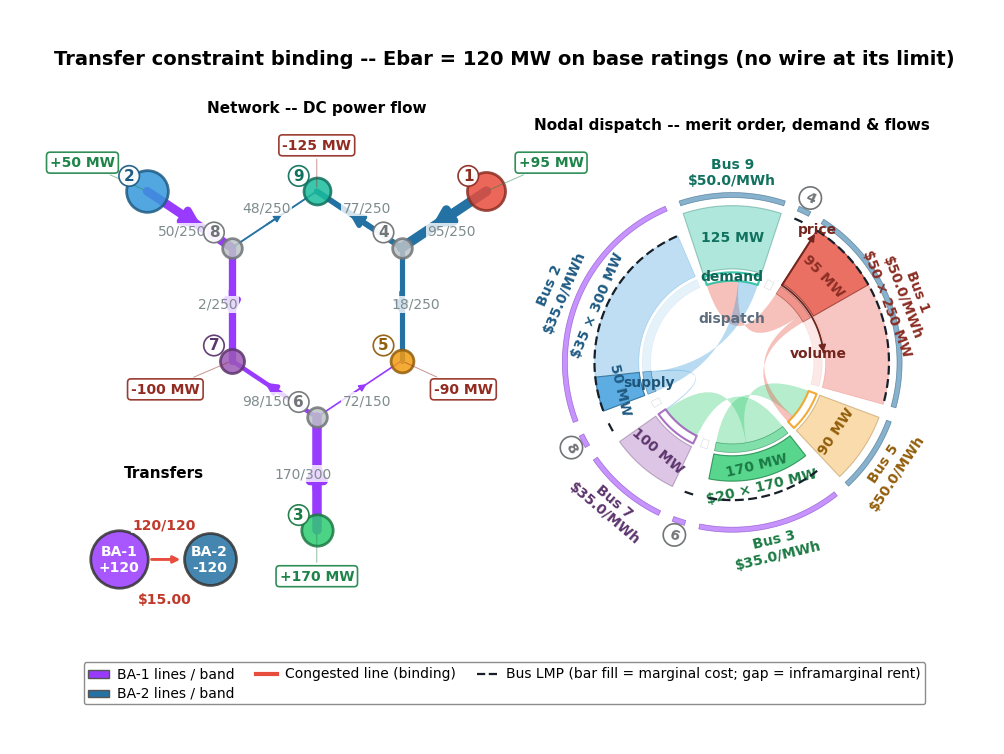

E = 120.0 MW at Ebar = 120  ->  mu_T = -15.00 $/MWh

  BA-1 LMPs:

{'2': np.float64(35.0), '8': np.float64(35.0), '7': np.float64(35.0), '6': np.float64(35.0), '3': np.float64(35.0)}

  BA-2 LMPs:

{'1': np.float64(50.0), '9': np.float64(50.0), '4': np.float64(50.0), '5': np.float64(50.0)}

...

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines



Ledger -- autarky vs constrained trade; transfer rent by T1 -- fixed shares (TRANSFER_SPLIT)  (congestion Method 1: tau = 0, methods coincide):

BA-1               BA-2              TOTAL
                                                 Consumer Generator Consumer Generator         
Autarky Accommodation: payment / revenue          -2000.0    2000.0 -10750.0   10750.0      0.0
Autarky Accommodation: production cost                      -2000.0           -10750.0 -12750.0
Autarky Accommodation: own congestion rent (CRR)      0.0                0.0                0.0
Autarky Accommodation: position                   -2000.0       0.0 -10750.0       0.0 -12750.0
Constrained: payment / revenue                    -3500.0    7700.0 -10750.0    4750.0  -1800.0
Constrained: production cost                                -5150.0            -4750.0  -9900.0
Congestion rent collected (assigned lines)            0.0                0.0                0.0
Congestion rent allocated (CRR)                       0.0                0.0                0.0
Transfer rent collected (border)                                                         1800.0
Transfer rent allocated (CRR)                       900.0              900.0             1800.0
Final position                                    -2600.0    2550.0  -9850.0       0.0  -9900.0
Delta vs autarky accommodation                     -600.0    2550.0    900.0       0.0   2850.0
Pareto (Delta >= 0)                                    no       yes      yes       yes


Ledger -- autarky vs constrained trade; transfer rent by T2 -- all to the net-payer BA  (congestion Method 1: tau = 0, methods coincide):

BA-1               BA-2              TOTAL
                                                 Consumer Generator Consumer Generator         
Autarky Accommodation: payment / revenue          -2000.0    2000.0 -10750.0   10750.0      0.0
Autarky Accommodation: production cost                      -2000.0           -10750.0 -12750.0
Autarky Accommodation: own congestion rent (CRR)      0.0                0.0                0.0
Autarky Accommodation: position                   -2000.0       0.0 -10750.0       0.0 -12750.0
Constrained: payment / revenue                    -3500.0    7700.0 -10750.0    4750.0  -1800.0
Constrained: production cost                                -5150.0            -4750.0  -9900.0
Congestion rent collected (assigned lines)            0.0                0.0                0.0
Congestion rent allocated (CRR)                       0.0                0.0                0.0
Transfer rent collected (border)                                                         1800.0
Transfer rent allocated (CRR)                         0.0             1800.0             1800.0
Final position                                    -3500.0    2550.0  -8950.0       0.0  -9900.0
Delta vs autarky accommodation                    -1500.0    2550.0   1800.0       0.0   2850.0
Pareto (Delta >= 0)                                    no       yes      yes       yes

In [22]:
# -- EDIT -- bind the border: schedule less than the network wants to move ------
XFER_BIND = 120.0          # Ebar below the ~215 MW unconstrained interchange
# ------------------------------------------------------------------------------
netX, ptX, engX, resX = solve_with_transfer({}, XFER_BIND)
fig = transfer_figure(netX, ptX, engX, resX, XFER_BIND,
                      suptitle=f'Transfer constraint binding -- Ebar = {XFER_BIND:.0f} MW '
                               f'on base ratings (no wire at its limit)')
size_for_print(fig)
plt.show()

RT = transfer_rent(resX)
print(f'E = {resX.interchange_mw:.1f} MW at Ebar = {XFER_BIND:.0f}'
      f'  ->  mu_T = {resX.interchange_dual:.2f} $/MWh')
print('  BA-1 LMPs:', {bb: round(resX.lmp[bb], 1) for bb in BA_DEFS['BA-1']})
print('  BA-2 LMPs:', {bb: round(resX.lmp[bb], 1) for bb in BA_DEFS['BA-2']})
print('binding lines:', {l: round(mu, 1) for l, mu in resX.line_dual.items()
                         if abs(mu) > 1e-3} or 'none')

# Tested like the congestion-rent methodology: the settlement wedge must equal R + R_T.
sX = ba_settlement(resX, LOADS_ALL)
wedge = sum(sX[ba]['net_into_pool'] for ba in BA_DEFS)
_, summX, lrX, _ = allocate_congestion_rent(resX, ptX, LOADS_ALL)
print(f'\nconservation:  load pays - gen paid = {wedge:,.1f}   vs   R + R_T = '
      f'{summX["R"]:,.1f} + {RT:,.1f} = {summX["R"] + RT:,.1f}')

print('\ncross-border price-gap decomposition (border_separation) -- raw gap = line congestion + transfer:')
display(border_separation(resX, ptX)[['flow', 'dlam', 'dlam_cong', 'dlam_xfer', 'sep_rent']].round({'sep_rent': 1}))

# Autarky Accommodation counterfactual on the SAME (base) ratings (BA-2 exogenous, BA-1
# accommodates); with no line binding this coincides with pure autarky here.
indepX = accommodation_baseline({})

# No line binds, so the congestion-priced separation is 0 as well as R: the
# congestion methods coincide and the TRANSFER methodology is the only live
# allocation choice -- one ledger per configured transfer rule. Transfer rent
# is COLLECTED at the border (TOTAL column) and ALLOCATED per the rule; the
# autarky block and Pareto row ask who the constrained trade leaves better off.
for _t in TRANSFER_METHODS:
    print(f'\nLedger -- autarky vs constrained trade; transfer rent by {T_NAMES.get(_t, _t)}'
          f'  (congestion Method {CONGESTION_METHODS[0]}: tau = 0, methods coincide):')
    display(relabel_accom(transfer_ledger(resX, ptX, LOADS_ALL, CONGESTION_METHODS[0], _t, indepX)))


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


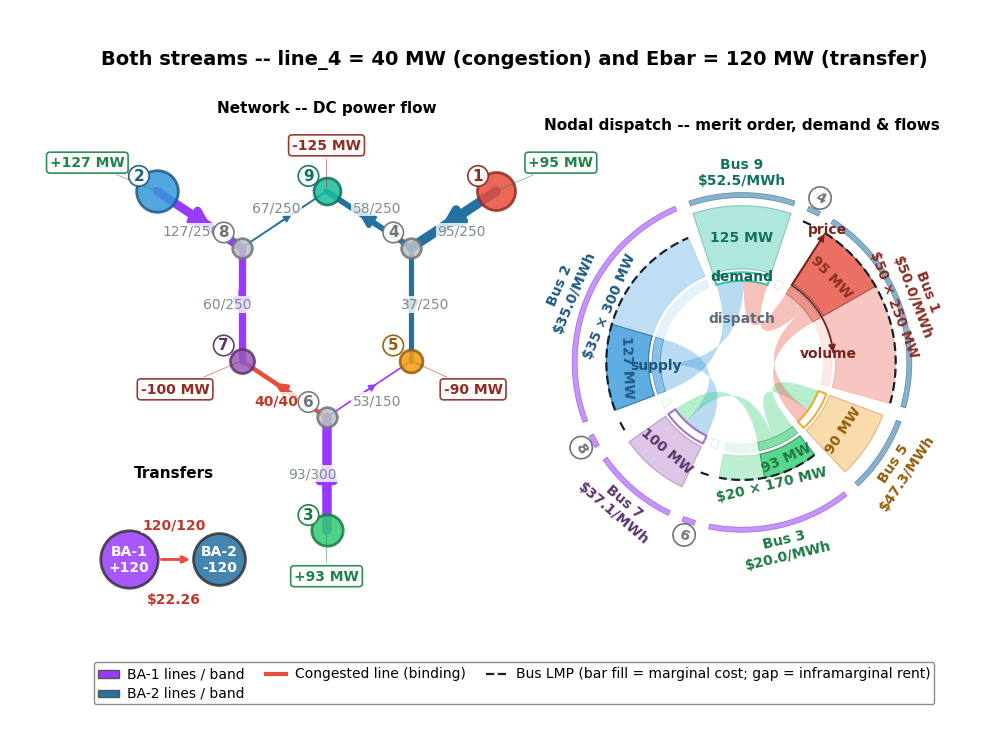

binding lines:

{'line_4': -20.1}

 |  E = 120 MW,  mu_T = -22.26


per-line congestion rent (binding lines):

,frm,to,kind,home,mu,flow,rent
line,,,,,,,
line_4,6,7,internal,BA-1,-20.1,40.0,804.1


...

BA-1               BA-2              TOTAL
                                                 Consumer Generator Consumer Generator         
Autarky Accommodation: payment / revenue          -3712.6    2977.7 -10750.0   10750.0   -734.9
Autarky Accommodation: production cost                      -2977.7           -10750.0 -13727.7
Autarky Accommodation: own congestion rent (CRR)    734.9                0.0              734.9
Autarky Accommodation: position                   -2977.7       0.0 -10750.0       0.0 -13727.7
Constrained: payment / revenue                    -3712.6    6306.1 -10819.2    4750.0  -3475.7
Constrained: production cost                                -6306.1            -4750.0 -11056.1
Congestion rent collected (assigned lines)          804.1                0.0              804.1
Congestion rent allocated (CRR)                     804.1                0.0              804.1
Transfer rent collected (border)                                                         2671.7
Transfer rent allocated (CRR)                         0.0             2671.7             2671.7
Final position                                    -2908.5       0.0  -8147.6       0.0 -11056.1
Delta vs autarky accommodation                       69.2       0.0   2602.4       0.0   2671.7
Pareto (Delta >= 0)                                   yes       yes      yes       yes


Method 2 -- each BA keeps the congestion revenue its gen-to-load creates (N_a^c);  transfer rent by T1 -- fixed shares (TRANSFER_SPLIT):

BA-1               BA-2              TOTAL
                                                 Consumer Generator Consumer Generator         
Autarky Accommodation: payment / revenue          -3712.6    2977.7 -10750.0   10750.0   -734.9
Autarky Accommodation: production cost                      -2977.7           -10750.0 -13727.7
Autarky Accommodation: own congestion rent (CRR)    734.9                0.0              734.9
Autarky Accommodation: position                   -2977.7       0.0 -10750.0       0.0 -13727.7
Constrained: payment / revenue                    -3712.6    6306.1 -10819.2    4750.0  -3475.7
Constrained: production cost                                -6306.1            -4750.0 -11056.1
Congestion rent collected (assigned lines)          804.1                0.0              804.1
Congestion rent allocated (CRR)                     734.9               69.2              804.1
Transfer rent collected (border)                                                         2671.7
Transfer rent allocated (CRR)                      1335.8             1335.8             2671.7
Final position                                    -1641.9       0.0  -9414.2       0.0 -11056.1
Delta vs autarky accommodation                     1335.8       0.0   1335.8       0.0   2671.7
Pareto (Delta >= 0)                                   yes       yes      yes       yes


Method 2 -- each BA keeps the congestion revenue its gen-to-load creates (N_a^c);  transfer rent by T2 -- all to the net-payer BA:

BA-1               BA-2              TOTAL
                                                 Consumer Generator Consumer Generator         
Autarky Accommodation: payment / revenue          -3712.6    2977.7 -10750.0   10750.0   -734.9
Autarky Accommodation: production cost                      -2977.7           -10750.0 -13727.7
Autarky Accommodation: own congestion rent (CRR)    734.9                0.0              734.9
Autarky Accommodation: position                   -2977.7       0.0 -10750.0       0.0 -13727.7
Constrained: payment / revenue                    -3712.6    6306.1 -10819.2    4750.0  -3475.7
Constrained: production cost                                -6306.1            -4750.0 -11056.1
Congestion rent collected (assigned lines)          804.1                0.0              804.1
Congestion rent allocated (CRR)                     734.9               69.2              804.1
Transfer rent collected (border)                                                         2671.7
Transfer rent allocated (CRR)                         0.0             2671.7             2671.7
Final position                                    -2977.7       0.0  -8078.3       0.0 -11056.1
Delta vs autarky accommodation                        0.0       0.0   2671.7       0.0   2671.7
Pareto (Delta >= 0)                                   yes       yes      yes       yes

In [23]:
# Both revenue streams at once: the internal line limit AND the binding border.
# line_4 (6-7, internal to BA-1) at 40 MW collects congestion rent on BA-1's
# wires; the schedule at Ebar = XFER_BIND collects transfer rent on the border.
netC, ptC, engC, resC = solve_with_transfer(dict(LINE_RATINGS), XFER_BIND)
fig = transfer_figure(netC, ptC, engC, resC, XFER_BIND,
                      suptitle=f'Both streams -- line_4 = {LINE_RATINGS["line_4"]:.0f} MW '
                               f'(congestion) and Ebar = {XFER_BIND:.0f} MW (transfer)')
size_for_print(fig)
plt.show()

RTC = transfer_rent(resC)
allocC, summC, lrC, sepC = allocate_congestion_rent(resC, ptC, LOADS_ALL)
print('binding lines:', {l: round(mu, 1) for l, mu in resC.line_dual.items()
                         if abs(mu) > 1e-3},
      f' |  E = {resC.interchange_mw:.0f} MW,  mu_T = {resC.interchange_dual:.2f}')
print('\nper-line congestion rent (binding lines):')
display(lrC[lrC.rent > 1e-3].round({'rent': 1}))

print('cross-border price-gap decomposition (border_separation) -- raw gap = line congestion + transfer;')
print('Method 2 moves only the congestion part (tau), the transfer part is settled as R_T:')
display(sepC[['flow', 'dlam', 'dlam_cong', 'dlam_xfer', 'sep_rent']].round({'sep_rent': 1}))

sC = ba_settlement(resC, LOADS_ALL)
wedgeC = sum(sC[ba]['net_into_pool'] for ba in BA_DEFS)
print(f'conservation:  load pays - gen paid = {wedgeC:,.1f}   vs   R + R_T = '
      f'{summC["R"]:,.1f} + {RTC:,.1f} = {summC["R"] + RTC:,.1f}')

# Autarky Accommodation counterfactual on the SAME ratings (BA-2 exogenous, BA-1 accommodates
# the loop flow on line_4) -- the same baseline as the Section-4 Pareto ledger.
indepC = accommodation_baseline(dict(LINE_RATINGS))
_M_NAMES = {1: 'Method 1 -- congestion rent stays with the managing BA',
            2: 'Method 2 -- each BA keeps the congestion revenue its gen-to-load creates (N_a^c)'}
# One ledger per configured (congestion, transfer) methodology pair -- trim
# either list in the EDIT cell to show fewer tables. Only the two allocated
# rows move between tables; collected rows and every total are invariant.
for _m in CONGESTION_METHODS:
    for _t in TRANSFER_METHODS:
        print('\n' + _M_NAMES.get(_m, f'Method {_m}')
              + f';  transfer rent by {T_NAMES.get(_t, _t)}:')
        display(relabel_accom(transfer_ledger(resC, ptC, LOADS_ALL, _m, _t, indepC)))


**Read it.** With only the border constrained (middle example) prices are flat
within each BA — two energy prices linked by a constrained schedule, EDAM's
per-BAA structure in miniature — and the whole settlement wedge is transfer
rent, $R_T=|\mu_T E|$, split by the configured shares. With `line_4` back at 40 MW (last example)
the **two revenue streams coexist**: BA-1's internal wire collects congestion
rent $R$ exactly as in Section 3, the border schedule collects $R_T$ on top, and
the wedge is their sum — the conservation line checks it to the cent. Note the
interplay: with the internal limit in place $|\mu_T|$ is *larger* than in the
pure-border case, because the redispatch the schedule forces interacts with the
congested wire.

The middle example is also where the tie price-gap split (`border_separation`) earns its
keep. The raw price gap across each tie is $|\mu_T|$ — but no **line** is binding,
so the congestion component of that gap is zero — no line rent to split ($R=0$) — and Methods 1 and 2
genuinely coincide: the border's separation is settled once, as $R_T$, not a second
time through a rebate. In the combined example the decomposition table makes the
same point line by line: each tie's raw gap splits into a line-congestion part
(`dlam_cong`, the piece that feeds the congestion rent $R$ — which Method 2 redistributes as each area's $N^c$) and a transfer part
(`dlam_xfer` $=\pm\mu_T$, settled as $R_T$ by the configured transfer rule) — every dollar of separation
settled exactly once, by the constraint that created it.

The autarky block prices the distributional story. Constrained trade still
beats autarky in total — the TOTAL of the *Delta vs autarky accommodation* row is exactly the
production-cost saving — but the gains need not reach everyone. In the middle
example BA-1's **consumers** end up *worse* than autarky (the export pulls
their cheap unit away and their price rises from \$20 toward the importer's
\$50) even as BA-1's **generators** gain several times that: the border fails the
Pareto check on one column. With `line_4` back at 40 MW the autarky baseline is
itself expensive enough that every column clears the check under the default
50/50 — but the methodology grid has corners: stack **both** rebates on the
net-payer (Method 2 x T2) and the exporter's consumers drop below autarky
again, while Method 1 x T2 leaves them exactly at their autarky position. How much of each rent is
rebated to whom — `CONGESTION_METHODS`, `TRANSFER_METHODS` — is what decides
whether integrating across the border is merely efficient or actually Pareto-improving:
switching the transfer rule from T1 to T2 moves the whole rebate to the
importer and *deepens* the exporter-consumer loss — the methodology choice is
pure distribution, the production-cost saving never moves.



## UNDER DEVELOPMENT
the rest of the notebook is still under development

## 6. The self-schedule incentive

Sections 4–5 asked *how to split* the rent the clearing collects. This section
asks the prior question a participant faces: does the splitting rule change what
it **bids**? An allocation is stable only if, taking the rule as given, no party
can profit by gaming the schedule the rule keys on.

Hold the network at the base ratings and bind the transfer constraint of eq. (2)
below the cheap exporter's reach, so BA-1 sits at its \$20 unit and BA-2 at its
\$50 unit — a seam gap of \$30 with no wire at its limit (eq. 4, with $\mu_T$
the only binding term). The \$35 unit at bus 2 is then **off**: its bus LMP, \$20,
is below its cost.

Now let a firm-rights holder recover the congestion charge on a balanced
self-schedule along its right's path — the parallel-flow rebate. Writing $S$ for
the self-scheduled megawatts from a source bus to a sink bus, the rebate is the
border price gap the right spans times the flow,

$$\rho=\big(\lambda_{\mathrm{sink}}-\lambda_{\mathrm{source}}\big)\,S, \qquad (15)$$

and the holder's all-in cost of meeting $S$ collapses from the sink price to the
resource's own cost:

$$\underbrace{c_{\mathrm{source}}\,S}_{\text{fuel}}
  +\underbrace{(\lambda_{\mathrm{sink}}-\lambda_{\mathrm{source}})\,S}_{\text{congestion charge}}
  -\underbrace{\rho}_{\text{rebate}}
  \;=\;c_{\mathrm{source}}\,S
  \;<\;\underbrace{\lambda_{\mathrm{sink}}\,S}_{\text{buy at the market}}. \qquad (16)$$

So a rule that rebates $\rho$ makes it privately rational to self-schedule the
\$35 unit even though the market leaves it off. Because the transfer constraint
caps BA-1's export, forcing the \$35 unit on backs the \$20 unit down by $S$ — a
price-taking injection (`exo={source: +S}`): the same megawatts cross the seam,
now sourced from a costlier unit. The holder's saving,
$(\lambda_{\mathrm{sink}}-c_{\mathrm{source}})\,S$, is matched dollar-for-dollar
by a draw on the rent pool — part a transfer, part pure waste. The next cells
clear it both ways and settle the result.

In [24]:
# -- EDIT -- the self-schedule scenario --------------------------------------
SS_TRANSFER_LIMIT = 60.0               # Ebar (MW): cap BA-1's export so BA-1 sits at $20, BA-2 at $50
SELF_SCHEDULE     = ('2', '9', 40.0)   # (source bus, sink bus, MW) -- the $35 bus-2 unit on a firm 2->9 right
# ----------------------------------------------------------------------------
print(f'scenario: Ebar = {SS_TRANSFER_LIMIT:.0f} MW;  self-schedule '
      f'{SELF_SCHEDULE[2]:.0f} MW  bus {SELF_SCHEDULE[0]} -> bus {SELF_SCHEDULE[1]}')

scenario: Ebar = 60 MW;  self-schedule 40 MW  bus 2 -> bus 9

INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


transfer limit binds -> BA-1 at $20, BA-2 at $50 (seam gap $30); the $35 unit at bus 2 is OFF economically.

self-scheduling 40 MW on the firm 2->9 right rebates the congestion charge $30 x 40 = $1,200,

so its all-in cost falls to $35/MWh -- a private gain of $600/h -- while the cheap unit backs down and production cost rises $600/h.

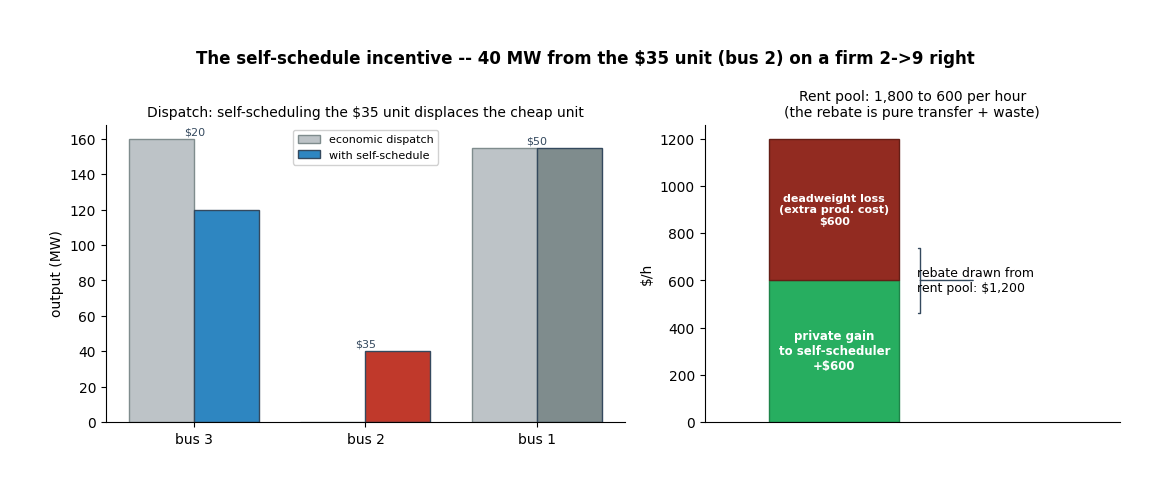


Who gains, who pays -- positions $/h (negative = cash out; the firm customer is

carved out as a separate party in BOTH columns, so the comparison is apples-to-apples):

,Economic,Self-schedule,Change
BA-1 consumers,-2000.0,-2000.0,0.0
BA-1 generators,0.0,0.0,0.0
BA-2 consumers,-8750.0,-8750.0,0.0
BA-2 generators,0.0,0.0,0.0
Self-schedule (firm right),-2000.0,-1400.0,600.0
Congestion + transfer rent pool,1800.0,600.0,-1200.0
TOTAL (= -production cost),-10950.0,-11550.0,-600.0


       Economic: positions sum  -10,950.0   vs   -(production cost)  -10,950.0

  Self-schedule: positions sum  -11,550.0   vs   -(production cost)  -11,550.0

  -> the $1,200 rebate splits into $600 private transfer + $600 deadweight, drawn entirely from the rent pool.

In [25]:
# Economic dispatch vs the firm-rights self-schedule: the conserving ledger
# (revenue_allocation.self_schedule_ledger) and the figure (wscc9_figures); bound to fp.
led, ss = ra.self_schedule_ledger(fp, SS_TRANSFER_LIMIT, *SELF_SCHEDULE, loads=LOADS_ALL)
src, snk, S = SELF_SCHEDULE

print(f'transfer limit binds -> BA-1 at ${ss["lmp_source"]:.0f}, BA-2 at ${ss["lmp_sink"]:.0f} '
      f'(seam gap ${ss["gap"]:.0f}); the ${ss["src_cost"]:.0f} unit at bus {src} is OFF economically.')
print(f'self-scheduling {S:.0f} MW on the firm {src}->{snk} right rebates the congestion charge '
      f'${ss["gap"]:.0f} x {S:.0f} = ${ss["rebate"]:,.0f},')
print(f'so its all-in cost falls to ${ss["src_cost"]:.0f}/MWh -- a private gain of '
      f'${ss["private_gain"]:,.0f}/h -- while the cheap unit backs down and production cost '
      f'rises ${ss["deadweight"]:,.0f}/h.')

fig = figs.self_schedule_figure(ss, suptitle=f'The self-schedule incentive -- {S:.0f} MW '
                                f'from the ${ss["src_cost"]:.0f} unit (bus {src}) on a firm '
                                f'{src}->{snk} right')
plt.show()

print('\nWho gains, who pays -- positions $/h (negative = cash out; the firm customer is')
print('carved out as a separate party in BOTH columns, so the comparison is apples-to-apples):')
display(led)

# Conservation: every non-TOTAL position sums to -(production cost) in each column.
nonT = led.drop(index='TOTAL (= -production cost)')
for c in ['Economic', 'Self-schedule']:
    print(f'  {c:>13}: positions sum {nonT[c].sum():>10,.1f}   vs   -(production cost) '
          f'{led.loc["TOTAL (= -production cost)", c]:>10,.1f}')
print(f'  -> the ${ss["rebate"]:,.0f} rebate splits into ${ss["private_gain"]:,.0f} private '
      f'transfer + ${ss["deadweight"]:,.0f} deadweight, drawn entirely from the rent pool.')

**Read it.** Keying the rebate to *scheduling behaviour* is what makes the rule
unstable. The self-schedule above conserves to the penny — every ordinary party
(both BAs' consumers and generators) is untouched — yet it hands the
self-scheduler **+\$600/h**, drawn from an **\$1,800/h** rent pool, and **\$600/h**
of that draw is pure production-cost waste: the \$20 unit that should have exported
is idled so the \$35 unit can run for the same megawatts across the seam. The
resource no longer faces the cost of the congestion it causes — cost-causation is
diluted: economically it stayed off; under the rebate it runs and is made whole.
And the incentive compounds — every megawatt self-scheduled to capture the rebate
displaces cheaper energy and can deepen the very congestion the schedule is paid
for, a feedback this static ledger only begins to show. A rule settled on a *fixed
financial entitlement* — paid for holding the right, not for self-scheduling
against it — breaks the link between the rent split and how each resource bids.

In [26]:
# === Export 600-DPI figures for the status-quo-merchandising lab note (local only) ===
import os as _os
_OUT = _os.path.abspath(_os.path.join("notes", "status_quo_merchandising", "figures"))
_os.makedirs(_OUT, exist_ok=True)
import matplotlib.patches as _mp

# (a) the two-balancing-authority network map
_bc = {b: BA_COLORS[ba_of(b)] for b in pt.buses}
_f1, _a1 = plot_network_topology(
    build_network(), supply_by_bus={}, demand_by_bus={}, bus_colors=_bc, bus_coords=COORDS,
    line_flows={l: 0.0 for l in pt.lines}, line_widths=susceptance_widths(pt),
    line_colors=ba_line_colors(pt),
    title="Two balancing authorities on the WSCC 9-bus network")
for _l in ties:
    _i = pt.line_idx[_l]; _b0, _b1 = pt.line_buses[_i]
    _x0, _y0 = COORDS[_b0]; _x1, _y1 = COORDS[_b1]
    _a1.text((_x0+_x1)/2, (_y0+_y1)/2, f"TIE {_b0}-{_b1}", fontsize=8, fontweight="bold",
             color="#117A2B", ha="center", va="center",
             bbox=dict(fc="white", ec="#117A2B", alpha=0.9, pad=1.5), zorder=7)
_a1.legend(handles=[_mp.Patch(color=BA_COLORS[ba], label=ba) for ba in BA_DEFS],
           loc="lower left", fontsize=9, framealpha=0.9)
_f1.savefig(_os.path.join(_OUT, "fig_network_bas.png"), dpi=600, bbox_inches="tight")

# (The three dispatch views -- islanded / neighbour-fixed / unified -- are exported by Section 3.)
print("wrote the network map to", _OUT)
import matplotlib.pyplot as _plt; _plt.close(_f1)  # don't embed the 600-DPI fig in the notebook


INFO:ieee9_network:Imported IEEE 9-bus: 9 buses, 3 gens, 3 loads, 9 lines


wrote the network map to

C:\Users\docke\Projects\wscc9-illustrative-models\notes\status_quo_merchandising\figures